In [ ]:
# CELDA 002
'''
Relacionar google drive con Collab, para poder usar mi drive como almacenamiento de archivos,
y como lugar donde van a reposar los outputs que se generen en este script.
'''

from google.colab import drive
drive.mount('/content/t10drive')
# Ejecutar el código anterior y aceptar lo solicitado; permisos y accesos

Mounted at /content/t10drive


In [ ]:
# CELDA 003
'''
Definir las rutas para acceder a los datos.
'''

import os  # Paquete para manejar carpetas, direcciones y archivos

# === RUTAS BASE ===
base = '/content/t10drive/MyDrive/taller10'   # Carpeta raíz del proyecto
datos = os.path.join(base, 'datos')  # Carpeta de datos
outputs = os.path.join(base, 'outputs')  # Carpeta de outputs
figuras = os.path.join(outputs, 'figuras')  # Carpeta de figuras
codes = os.path.join(base, 'codes')  # Carpeta de códigos

# Crear las carpetas/rutas si no existen
os.makedirs(datos, exist_ok=True)
os.makedirs(outputs, exist_ok=True)
os.makedirs(figuras, exist_ok=True)
os.makedirs(codes, exist_ok=True)

In [ ]:
# CELDA 004

import os
import pandas as pd
from google.colab import files
import shutil # Importamos el módulo shutil para mover archivos entre diferentes sistemas de archivos

# Subir archivo desde el dispositivo
print("Por favor, selecciona el archivo a cargar:")
uploaded = files.upload()

# Obtener el nombre del archivo cargado
for filename in uploaded.keys():
    uploaded_filename = filename
    break

if 'uploaded_filename' in locals():
    # Definir la ruta de destino en la carpeta 'datos'
    destination_path = os.path.join(datos, uploaded_filename)

    # Mover el archivo cargado a la carpeta 'datos' usando shutil.move
    # shutil.move maneja el caso de mover entre diferentes sistemas de archivos
    shutil.move(uploaded_filename, destination_path)
    print(f"'{{uploaded_filename}}' ha sido movido a '{{datos}}'")

    # Mostrar el tamaño del archivo
    file_size = os.path.getsize(destination_path)
    print(f"\nTamaño del archivo: {{file_size / (1024 * 1024):.2f}} MB")

    # Cargar el archivo en un DataFrame de pandas
    # Se asume que es un archivo CSV. Si es otro formato (ej. Excel), ajustar pd.read_excel
    try:
        df = pd.read_csv(destination_path, sep=';') # AÑADIDO: sep=';' para leer correctamente las columnas

        # Guardar una referencia a la ruta del archivo cargado (opcional, para uso futuro)
        last_uploaded_file_path = destination_path
        print(f"La ruta del último archivo cargado se ha guardado en 'last_uploaded_file_path': {{last_uploaded_file_path}}")

        # Mostrar los nombres de los campos (columnas)
        print("\nNombres de los campos (columnas):")
        print(df.columns.tolist())

        # Mostrar los primeros 5 registros
        print("\nPrimeros 5 registros:")
        display(df.head())
    except Exception as e:
        print(f"Error al cargar el archivo con pandas: {e}")
        print("Por favor, asegúrate de que el archivo sea un formato legible (ej. CSV) y que el delimitador sea correcto.")
else:
    print("No se ha seleccionado ningún archivo.")

Por favor, selecciona el archivo a cargar:


Saving trm_taller.csv to trm_taller.csv
'{uploaded_filename}' ha sido movido a '{datos}'

Tamaño del archivo: {file_size / (1024 * 1024):.2f} MB
La ruta del último archivo cargado se ha guardado en 'last_uploaded_file_path': {last_uploaded_file_path}

Nombres de los campos (columnas):
['date', 'trm', 'day', 'xi', 'z', 'oil', 'dol_wg', 'vix']

Primeros 5 registros:


,date,trm,day,xi,z,oil,dol_wg,vix
0,8/11/2023,4005.06,3,29.97,1.064436,75.31,122.40550,14.45
1,9/11/2023,4065.79,4,60.73,2.147542,75.75,122.44340,15.29
2,10/11/2023,4056.94,5,-8.85,-0.302473,77.15,122.59115,14.17
3,13/11/2023,4037.19,1,-19.75,-0.686279,78.19,122.73890,14.76
4,14/11/2023,4037.19,2,0,0.009148,78.17,121.68650,14.16


In [ ]:
# CELDA 005

# Como CELDA 004 ahora lee el archivo con el delimitador ';', las columnas ya están separadas correctamente.
# Por lo tanto, no necesitamos la operación .str.split() ni reasignar los nombres de las columnas.

# Convertir la columna "date" a tipo fecha (datetime), asumiendo formato día/mes/año
print("Convirtiendo la columna 'date' a formato de fecha...")
df["date"] = pd.to_datetime(df["date"], format='%d/%m/%Y', dayfirst=True)

# Convertir las columnas numéricas a tipo numérico con pd.to_numeric, usando errors='coerce'
print("Convirtiendo columnas numéricas a tipo numérico...")
numeric_cols = ["trm", "day", "xi", "z", "oil", "dol_wg", "vix"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Ordenar el DataFrame por la columna "date" de forma ascendente y establecer "date" como índice
print("Ordenando el DataFrame por 'date' y estableciéndola como índice...")
df = df.sort_values(by="date", ascending=True)
df = df.set_index("date")

# Crear un nuevo DataFrame llamado data que contenga, al menos, las siguientes columnas:
# "z", "oil", "dol_wg", "vix"
# Haz que data sea una copia (.copy()) de esas columnas.
print("Creando 'data' con las columnas clave para el modelado...")
data = df[["z", "oil", "dol_wg", "vix"]].copy()

# Mostrar df.head() para ver la estructura completa ya limpia.
print("\nEstructura completa del DataFrame (df) ya limpio:")
display(df.head())

# Mostrar data.head() para ver las variables que usaremos como base del modelado.
print("\nVariables clave para el modelado en data:")
display(data.head())

Convirtiendo la columna 'date' a formato de fecha...
Convirtiendo columnas numéricas a tipo numérico...
Ordenando el DataFrame por 'date' y estableciéndola como índice...
Creando 'data' con las columnas clave para el modelado...

Estructura completa del DataFrame (df) ya limpio:


,trm,day,xi,z,oil,dol_wg,vix
date,,,,,,,
2023-11-08,4005.06,3,29.97,1.064436,75.31,122.40550,14.45
2023-11-09,4065.79,4,60.73,2.147542,75.75,122.44340,15.29
2023-11-10,4056.94,5,-8.85,-0.302473,77.15,122.59115,14.17
2023-11-13,4037.19,1,-19.75,-0.686279,78.19,122.73890,14.76
2023-11-14,4037.19,2,0.00,0.009148,78.17,121.68650,14.16



Variables clave para el modelado en data:


,z,oil,dol_wg,vix
date,,,,
2023-11-08,1.064436,75.31,122.40550,14.45
2023-11-09,2.147542,75.75,122.44340,15.29
2023-11-10,-0.302473,77.15,122.59115,14.17
2023-11-13,-0.686279,78.19,122.73890,14.76
2023-11-14,0.009148,78.17,121.68650,14.16


In [ ]:
# CELDA 006
'''
Esta celda se utiliza para realizar una exploración inicial del DataFrame 'data',
que contiene las variables clave para el modelado ('z', 'oil', 'dol_wg', 'vix').
Los objetivos son:
- Revisar la estructura básica del DataFrame (tipo, dimensiones, columnas).
- Verificar los tipos de datos de cada columna y del índice.
- Detectar la presencia de valores faltantes.
- Obtener un resumen estadístico descriptivo de las variables.
'''

import pandas as pd

print("--- Inspección de la estructura básica del DataFrame 'data' ---")
# 1. Inspeccionar estructura de data

# Mostrar el tipo de 'data' para confirmar que es un DataFrame de pandas.
print(f"Tipo de 'data': {type(data)}") # Esto confirma que 'data' es un DataFrame.

# Mostrar la forma (número de filas y columnas) del DataFrame.
print(f"Dimensiones de 'data' (filas, columnas): {data.shape}") # Esto indica la cantidad total de observaciones y variables.

# Listar los nombres de las columnas del DataFrame.
print(f"Nombres de las columnas de 'data': {data.columns.tolist()}") # Muestra las variables disponibles para el análisis.

print("\n--- Revisión de tipos de datos y el índice ---")
# 2. Revisar tipos de datos y el índice

# Mostrar información detallada del DataFrame, incluyendo tipos de datos, valores no nulos y uso de memoria.
data.info()
# Se espera que las columnas 'z', 'oil', 'dol_wg' y 'vix' sean de tipo numérico (float).
# Se espera que el índice del DataFrame sea de tipo fecha (DatetimeIndex), lo que es crucial para series de tiempo.

print("\n--- Revisión de valores faltantes ---")
# 3. Revisar valores faltantes

# Calcular y mostrar el número de valores nulos para cada columna en el DataFrame.
print("Número de valores nulos por columna:")
print(data.isna().sum())
# Este paso es fundamental para identificar si hay datos ausentes que requieran imputación o manejo antes del modelado.

print("\n--- Resumen estadístico básico ---")
# 4. Resumen estadístico básico

# Mostrar un resumen estadístico descriptivo de las columnas numéricas del DataFrame.
# Incluye la media, desviación estándar, valores mínimos, máximos y los cuartiles (25%, 50%, 75%).
print("Resumen estadístico de las variables clave:")
display(data.describe())

print("\n--- Vista rápida de los datos (primeras y últimas filas) ---")
# 5. Vista rápida de los datos

# Mostrar las primeras 5 filas del DataFrame.
print("Primeras 5 filas de 'data':")
display(data.head())

# Mostrar las últimas 5 filas del DataFrame.
print("Últimas 5 filas de 'data':")
display(data.tail())
# Estas vistas permiten verificar visualmente que los datos están cargados correctamente, las fechas están en orden cronológico
# y los valores de las variables parecen razonables dentro de su contexto.

--- Inspección de la estructura básica del DataFrame 'data' ---
Tipo de 'data': <class 'pandas.core.frame.DataFrame'>
Dimensiones de 'data' (filas, columnas): (522, 4)
Nombres de las columnas de 'data': ['z', 'oil', 'dol_wg', 'vix']

--- Revisión de tipos de datos y el índice ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 522 entries, 2023-11-08 to 2025-11-06
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   z       522 non-null    float64
 1   oil     522 non-null    float64
 2   dol_wg  522 non-null    float64
 3   vix     522 non-null    float64
dtypes: float64(4)
memory usage: 20.4 KB

--- Revisión de valores faltantes ---
Número de valores nulos por columna:
z         0
oil       0
dol_wg    0
vix       0
dtype: int64

--- Resumen estadístico básico ---
Resumen estadístico de las variables clave:


,z,oil,dol_wg,vix
count,5.220000e+02,522.000000,522.000000,522.000000
mean,-6.321840e-11,71.147835,123.116722,16.926475
std,1.000000e+00,6.699957,2.706837,4.788565
min,-3.013758e+00,57.130000,118.762000,11.860000
25%,-6.181444e-01,66.225000,121.112350,13.840000
50%,9.148240e-03,71.240000,122.319450,15.885000
75%,5.121443e-01,76.650000,124.511900,18.305000
max,5.080306e+00,86.100000,130.214200,52.330000



--- Vista rápida de los datos (primeras y últimas filas) ---
Primeras 5 filas de 'data':


,z,oil,dol_wg,vix
date,,,,
2023-11-08,1.064436,75.31,122.40550,14.45
2023-11-09,2.147542,75.75,122.44340,15.29
2023-11-10,-0.302473,77.15,122.59115,14.17
2023-11-13,-0.686279,78.19,122.73890,14.76
2023-11-14,0.009148,78.17,121.68650,14.16


Últimas 5 filas de 'data':


,z,oil,dol_wg,vix
date,,,,
2025-10-31,-0.514447,60.98,121.7715,17.44
2025-11-03,-0.353530,61.05,121.8422,17.17
2025-11-04,0.009148,60.56,122.2066,19.00
2025-11-05,0.444010,59.60,122.2295,18.01
2025-11-06,-1.152831,59.43,122.0788,19.50


In [ ]:
# CELDA 007
'''
Esta celda trabaja sobre el DataFrame 'data' existente para:
- Crear variables rezagadas (lags) de la columna 'z' para diferentes horizontes (de 1 a 5 días).
- Calcular promedios móviles y la volatilidad (desviación estándar móvil) de 'z'.
- Generar un solo DataFrame de trabajo ('data_model') que contendrá todas estas variables para el modelado.
'''

import pandas as pd

print("--- Creando DataFrame base 'data_model' como copia de 'data' ---")
# Crear un DataFrame llamado data_model como copia de data
data_model = data.copy()

print("\n--- Generando columnas rezagadas de 'z' (z_lag1 a z_lag5) ---")
# En data_model, crear las columnas de rezagos:
# z_lag1 = z rezagada 1 día.
# z_lag2 = z rezagada 2 días.
# z_lag3 = z rezagada 3 días.
# z_lag4 = z rezagada 4 días.
# z_lag5 = z rezagada 5 días.
for i in range(1, 6):
    data_model[f'z_lag{i}'] = data_model['z'].shift(i)
    print(f"Columna 'z_lag{i}' creada.")

print("\n--- Calculando promedio móvil (ma5_z) y desviación estándar móvil (sd5_z) de 'z' ---")
# En data_model, crear:
# ma5_z = promedio móvil de 5 días de z
data_model['ma5_z'] = data_model['z'].rolling(window=5).mean()
print("Columna 'ma5_z' creada.")
# sd5_z = desviación estándar móvil de 5 días de z
data_model['sd5_z'] = data_model['z'].rolling(window=5).std()
print("Columna 'sd5_z' creada.")

print("\n--- Verificando valores nulos en data_model ---")
# Mostrar data_model.isna().sum()
print("Número de valores nulos por columna en data_model:")
print(data_model.isna().sum())
# Los valores NaN aparecen en las primeras filas debido a las operaciones de rezago y promedios móviles,
# ya que no hay datos anteriores suficientes para calcularlos. Estos NaN no se eliminan aquí,
# porque cada modelo decidirá posteriormente qué columnas usar y filtrará los NaN según sus necesidades específicas.

print("\n--- Resumen rápido del dataset de trabajo (data_model) ---")
# Mostrar un resumen rápido del dataset de trabajo:

# data_model.shape
print(f"Dimensiones de data_model: {data_model.shape}")

# data_model.head() con las columnas principales
# Se selecciona un subconjunto de columnas para una visualización más limpia si existen.
columns_to_display = ['z', 'z_lag1', 'z_lag2', 'z_lag3', 'z_lag4', 'z_lag5', 'ma5_z', 'sd5_z', 'oil', 'dol_wg', 'vix']
# Filtrar las columnas que realmente existen en data_model
existing_columns = [col for col in columns_to_display if col in data_model.columns]

print("Primeras 5 filas de data_model (columnas principales):")
display(data_model[existing_columns].head())

--- Creando DataFrame base 'data_model' como copia de 'data' ---

--- Generando columnas rezagadas de 'z' (z_lag1 a z_lag5) ---
Columna 'z_lag1' creada.
Columna 'z_lag2' creada.
Columna 'z_lag3' creada.
Columna 'z_lag4' creada.
Columna 'z_lag5' creada.

--- Calculando promedio móvil (ma5_z) y desviación estándar móvil (sd5_z) de 'z' ---
Columna 'ma5_z' creada.
Columna 'sd5_z' creada.

--- Verificando valores nulos en data_model ---
Número de valores nulos por columna en data_model:
z         0
oil       0
dol_wg    0
vix       0
z_lag1    1
z_lag2    2
z_lag3    3
z_lag4    4
z_lag5    5
ma5_z     4
sd5_z     4
dtype: int64

--- Resumen rápido del dataset de trabajo (data_model) ---
Dimensiones de data_model: (522, 11)
Primeras 5 filas de data_model (columnas principales):


,z,z_lag1,z_lag2,z_lag3,z_lag4,z_lag5,ma5_z,sd5_z,oil,dol_wg,vix
date,,,,,,,,,,,
2023-11-08,1.064436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.31,122.40550,14.45
2023-11-09,2.147542,1.064436,NaN,NaN,NaN,NaN,NaN,NaN,75.75,122.44340,15.29
2023-11-10,-0.302473,2.147542,1.064436,NaN,NaN,NaN,NaN,NaN,77.15,122.59115,14.17
2023-11-13,-0.686279,-0.302473,2.147542,1.064436,NaN,NaN,NaN,NaN,78.19,122.73890,14.76
2023-11-14,0.009148,-0.686279,-0.302473,2.147542,1.064436,NaN,0.446475,1.15226,78.17,121.68650,14.16


--- Matriz de Correlación ---


,z,oil,dol_wg,vix,ma5_z,sd5_z
z,1.000000,-0.012553,0.051846,0.125430,0.392853,0.092113
oil,-0.012553,1.000000,0.054782,-0.455785,0.014203,-0.035046
dol_wg,0.051846,0.054782,1.000000,0.249272,0.088281,0.128529
vix,0.125430,-0.455785,0.249272,1.000000,0.211875,0.286066
ma5_z,0.392853,0.014203,0.088281,0.211875,1.000000,0.301010
sd5_z,0.092113,-0.035046,0.128529,0.286066,0.301010,1.000000


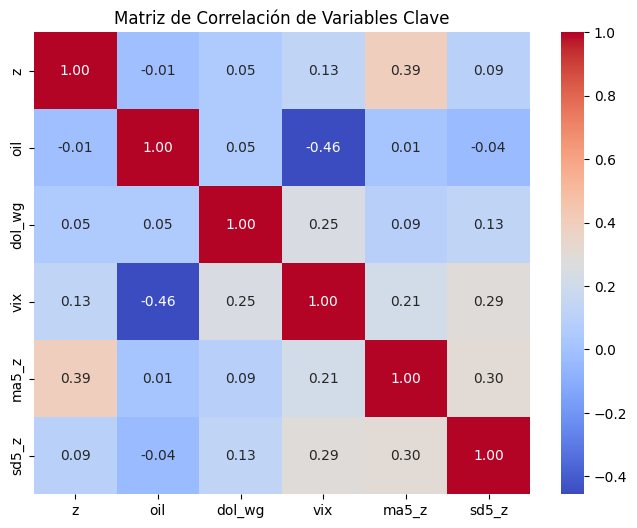


--- Visualización de Series de Tiempo ---


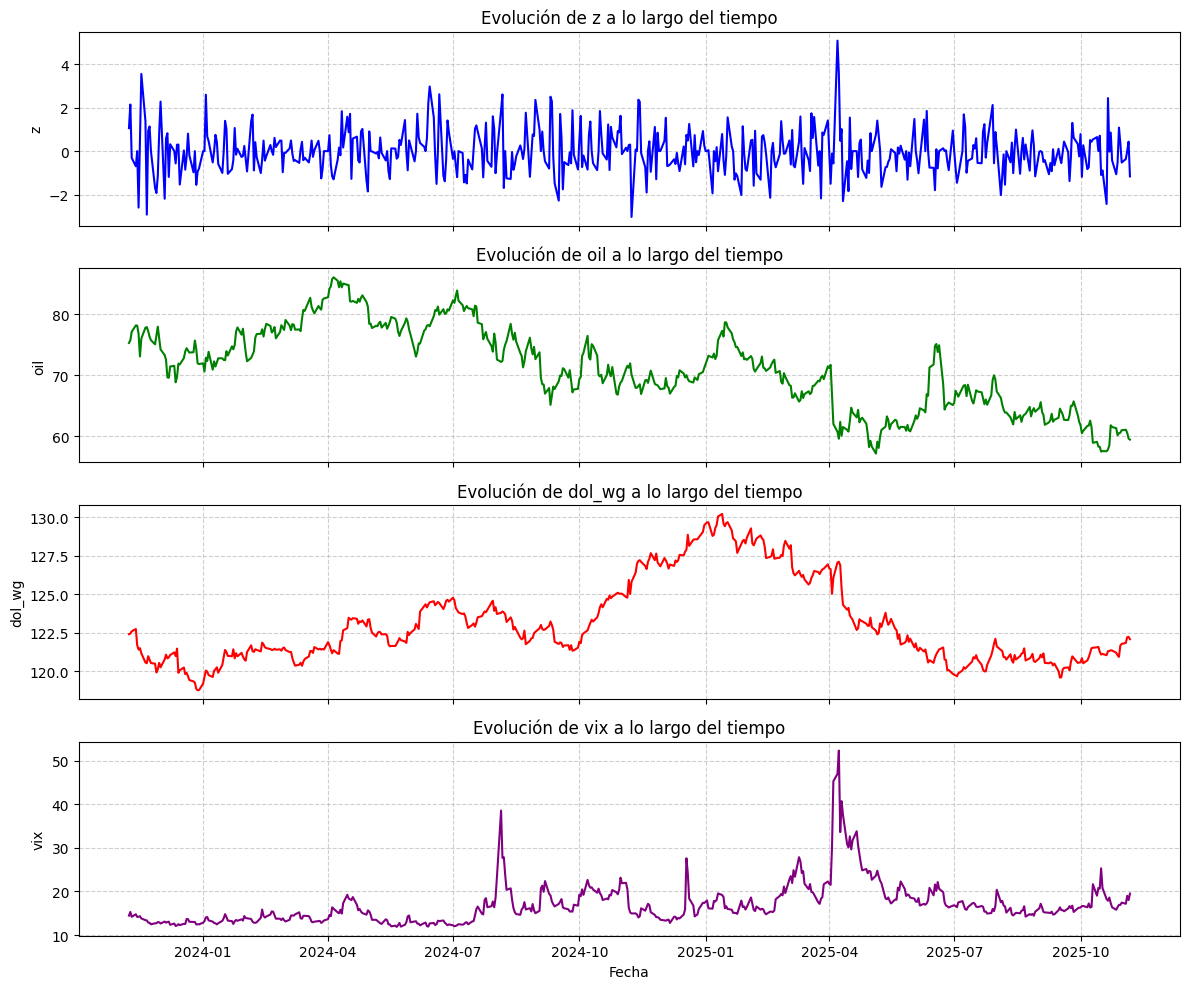

Figura guardada en: /content/t10drive/MyDrive/taller10/outputs/figuras/series_basicas.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# CELDA 008
'''
Esta celda realiza una exploración gráfica y numérica básica de las variables clave
(z, oil, dol_wg, vix, ma5_z, sd5_z) contenidas en el DataFrame 'data_model'.
Además, genera una visualización de series de tiempo para las variables principales
y guarda la figura resultante en la ruta definida en la variable 'figuras'.
'''

import matplotlib.pyplot as plt
import os # Para construir la ruta del archivo de salida
import pandas as pd # Aunque ya está importado en celdas anteriores, es buena práctica incluirlo si se usa.
import seaborn as sns # Opcional, pero mejora la estética de la matriz de correlación

print("--- Matriz de Correlación ---")
# Calcular y mostrar por pantalla la matriz de correlación entre las columnas seleccionadas.
# Esto sirve para ver relaciones lineales aproximadas entre las variables.
correlation_cols = ['z', 'oil', 'dol_wg', 'vix', 'ma5_z', 'sd5_z']

# Filtrar las columnas que realmente existen en data_model antes de calcular la correlación
existing_correlation_cols = [col for col in correlation_cols if col in data_model.columns]

if existing_correlation_cols:
    correlation_matrix = data_model[existing_correlation_cols].corr()
    display(correlation_matrix)
    # Opcional: Visualización más atractiva de la matriz de correlación
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Matriz de Correlación de Variables Clave')
    plt.show()
else:
    print("Ninguna de las columnas especificadas para la correlación existe en data_model.")

print("\n--- Visualización de Series de Tiempo ---")
# Crear una figura con 4 subgráficos (4 filas y 1 columna) que muestren en el tiempo:
# Subplot 1: z vs índice de fechas.
# Subplot 2: oil vs índice de fechas.
# Subplot 3: dol_wg vs índice de fechas.
# Subplot 4: vix vs índice de fechas.

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 10), sharex=True) # sharex=True para alinear los ejes X

# Subplot 1: z vs índice de fechas
axes[0].plot(data_model.index, data_model['z'], label='z', color='blue')
axes[0].set_title('Evolución de z a lo largo del tiempo')
axes[0].set_ylabel('z')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Subplot 2: oil vs índice de fechas
axes[1].plot(data_model.index, data_model['oil'], label='oil', color='green')
axes[1].set_title('Evolución de oil a lo largo del tiempo')
axes[1].set_ylabel('oil')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Subplot 3: dol_wg vs índice de fechas
axes[2].plot(data_model.index, data_model['dol_wg'], label='dol_wg', color='red')
axes[2].set_title('Evolución de dol_wg a lo largo del tiempo')
axes[2].set_ylabel('dol_wg')
axes[2].grid(True, linestyle='--', alpha=0.6)

# Subplot 4: vix vs índice de fechas
axes[3].plot(data_model.index, data_model['vix'], label='vix', color='purple')
axes[3].set_title('Evolución de vix a lo largo del tiempo')
axes[3].set_ylabel('vix')
axes[3].set_xlabel('Fecha') # Dejar la etiqueta del eje X solo en el último subplot
axes[3].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ajustar automáticamente los parámetros de la subtrama para dar un ajuste apretado
plt.show() # Mostrar la figura

# Guardar la figura en la carpeta figuras
file_path = os.path.join(figuras, "series_basicas.png")
plt.savefig(file_path)
print(f"Figura guardada en: {file_path}") # Indicando el nombre del archivo generado

In [ ]:
# CELDA 009
'''
Esta celda realiza dos funciones principales:
1. Resume las variables que están disponibles en el DataFrame 'data_model',
   identificando cuáles se pueden usar en los modelos.
2. Define una función auxiliar llamada 'preparar_dataset' que facilita la creación
   de sub-DataFrames limpios, seleccionando columnas específicas de 'data_model'
   y eliminando filas con valores nulos (NaN) únicamente en esas columnas seleccionadas.
   Esto asegura que cada modelo trabaje con datos completos para sus variables requeridas.
'''

import pandas as pd

print("--- Resumen de variables disponibles en data_model ---")
# Crear una lista llamada vars_disponibles que contenga las columnas especificadas
# (solo incluir las que existan realmente en data_model).
vars_deseadas = ['z', 'z_lag1', 'z_lag2', 'z_lag3', 'z_lag4', 'z_lag5', 'ma5_z', 'sd5_z', 'oil', 'dol_wg', 'vix']
vars_disponibles = [col for col in vars_deseadas if col in data_model.columns]

# Mostrar la lista en pantalla.
print(f"Variables disponibles para el modelado en data_model: {vars_disponibles}")

print("\n--- Definición de la función 'preparar_dataset' ---")
# Definir una función llamada preparar_dataset(columns) que:
# - reciba una lista de nombres de columnas (columns),
# - seleccione esas columnas desde data_model,
# - elimine filas con valores nulos en esas columnas (dropna),
# - devuelva el DataFrame resultante.

def preparar_dataset(columns):
    """
    Prepara un DataFrame para el modelado seleccionando columnas específicas de data_model
    y eliminando las filas que contienen valores nulos (NaN) en esas columnas.

    Args:
        columns (list): Lista de nombres de columnas a incluir en el dataset.

    Returns:
        pd.DataFrame: Un nuevo DataFrame con las columnas seleccionadas y sin NaNs en ellas.
    """
    print(f"Preparando dataset con las columnas: {columns}")
    # Seleccionar las columnas del data_model
    dataset = data_model[columns].copy()

    # Eliminar filas con valores nulos en las columnas seleccionadas
    dataset = dataset.dropna(subset=columns)

    return dataset

print("Función 'preparar_dataset' definida. Se usará para crear datasets limpios antes de ajustar cada tipo de modelo.\n")

print("--- Ejemplo de uso de 'preparar_dataset' ---")
# Como ejemplo, usar la función para crear dos datasets y mostrarlos:

# Dataset univariado con solo 'z'
data_univar = preparar_dataset(['z'])
print("\nDataset univariado (data_univar):")
print(f"Forma (shape): {data_univar.shape}")
display(data_univar.head())

# Dataset para un modelo autorregresivo de orden 3 (AR3)
data_ar3 = preparar_dataset(['z', 'z_lag1', 'z_lag2', 'z_lag3'])
print("\nDataset para modelo AR3 (data_ar3):")
print(f"Forma (shape): {data_ar3.shape}")
display(data_ar3.head())

--- Resumen de variables disponibles en data_model ---
Variables disponibles para el modelado en data_model: ['z', 'z_lag1', 'z_lag2', 'z_lag3', 'z_lag4', 'z_lag5', 'ma5_z', 'sd5_z', 'oil', 'dol_wg', 'vix']

--- Definición de la función 'preparar_dataset' ---
Función 'preparar_dataset' definida. Se usará para crear datasets limpios antes de ajustar cada tipo de modelo.

--- Ejemplo de uso de 'preparar_dataset' ---
Preparando dataset con las columnas: ['z']

Dataset univariado (data_univar):
Forma (shape): (522, 1)


,z
date,
2023-11-08,1.064436
2023-11-09,2.147542
2023-11-10,-0.302473
2023-11-13,-0.686279
2023-11-14,0.009148


Preparando dataset con las columnas: ['z', 'z_lag1', 'z_lag2', 'z_lag3']

Dataset para modelo AR3 (data_ar3):
Forma (shape): (519, 4)


,z,z_lag1,z_lag2,z_lag3
date,,,,
2023-11-13,-0.686279,-0.302473,2.147542,1.064436
2023-11-14,0.009148,-0.686279,-0.302473,2.147542
2023-11-15,-2.583121,0.009148,-0.686279,-0.302473
2023-11-16,0.476405,-2.583121,0.009148,-0.686279
2023-11-17,3.551424,0.476405,-2.583121,0.009148


In [ ]:
# CELDA 010
'''
Esta celda implementa y evalúa modelos de Promedio Móvil Simple (PMS) sobre la serie 'z'.
Para ello, prueba varias ventanas de tiempo para el cálculo del promedio móvil
y calcula métricas de error (MAE y RMSE) para determinar el rendimiento de cada modelo.
'''

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd # Asegurarse de que pandas esté importado si no lo está globalmente
import os # Para guardar el archivo CSV en la ruta de outputs

# Usar la función preparar_dataset para crear un dataset univariado de trabajo:
print("--- Preparando dataset univariado para la serie 'z' ---")
data_univar = preparar_dataset(['z'])

# Crear una serie z_series
z_series = data_univar['z']
print(f"Serie 'z_series' creada con {len(z_series)} observaciones.")

# Definir una lista de tamaños de ventana a evaluar
ventanas = [3, 5, 10, 20] # Representan el número de días usados para el promedio.
print(f"Ventanas a evaluar para el Promedio Móvil Simple: {ventanas}")

resultados_pms = []

print("\n--- Evaluando modelos de Promedio Móvil Simple (PMS) ---")
for k in ventanas:
    print(f"Calculando PMS para ventana = {k}...")
    # Construir una serie de pronóstico z_hat_k como el promedio móvil de los últimos k valores de z
    # El .shift(1) asegura que el pronóstico para un día se basa únicamente en datos pasados.
    z_hat_k = z_series.rolling(window=k).mean().shift(1)

    # Crear un DataFrame temporal con las columnas z_real (valores observados) y z_hat (pronóstico PMS)
    temp_df = pd.DataFrame({'z_real': z_series, 'z_hat': z_hat_k})

    # Eliminar filas con NaN en alguna de esas columnas para asegurar métricas válidas
    temp_df = temp_df.dropna()

    # Si no hay datos suficientes después de eliminar NaNs, continuar con la siguiente ventana
    if temp_df.empty:
        print(f"Advertencia: No hay datos suficientes para calcular métricas para la ventana {k} después de eliminar NaNs.")
        continue

    # Calcular MAE y RMSE
    mae = mean_absolute_error(temp_df['z_real'], temp_df['z_hat'])
    rmse = np.sqrt(mean_squared_error(temp_df['z_real'], temp_df['z_hat']))

    # Guardar los resultados en la lista
    resultados_pms.append({
        'ventana': k,
        'MAE': mae,
        'RMSE': rmse
    })
    print(f"Ventana {k}: MAE = {mae:.4f}, RMSE = {rmse:.4f}")

# Convertir la lista de diccionarios a un DataFrame para una mejor visualización
resultados_pms = pd.DataFrame(resultados_pms)

print("\n--- Resultados de la evaluación de modelos PMS ---")
# Mostrar la tabla resultados_pms
display(resultados_pms)

# Identificar y mostrar por pantalla qué tamaño de ventana tiene el menor RMSE
if not resultados_pms.empty:
    mejor_pms = resultados_pms.loc[resultados_pms['RMSE'].idxmin()]
    print(f"\nEl modelo PMS con el menor RMSE es la ventana de {int(mejor_pms['ventana'])} días, con RMSE = {mejor_pms['RMSE']:.4f}")
else:
    print("No se pudieron calcular resultados para los modelos PMS.")

# Guardar la tabla de resultados en la carpeta outputs
file_path = os.path.join(outputs, "resultados_pms.csv")
resultados_pms.to_csv(file_path, index=False)
print(f"\nTabla de resultados guardada en: {file_path}") # Documentar los resultados

--- Preparando dataset univariado para la serie 'z' ---
Preparando dataset con las columnas: ['z']
Serie 'z_series' creada con 522 observaciones.
Ventanas a evaluar para el Promedio Móvil Simple: [3, 5, 10, 20]

--- Evaluando modelos de Promedio Móvil Simple (PMS) ---
Calculando PMS para ventana = 3...
Ventana 3: MAE = 0.9058, RMSE = 1.2009
Calculando PMS para ventana = 5...
Ventana 5: MAE = 0.8333, RMSE = 1.1111
Calculando PMS para ventana = 10...
Ventana 10: MAE = 0.7773, RMSE = 1.0223
Calculando PMS para ventana = 20...
Ventana 20: MAE = 0.7522, RMSE = 0.9899

--- Resultados de la evaluación de modelos PMS ---


,ventana,MAE,RMSE
0,3,0.905846,1.200892
1,5,0.833346,1.111142
2,10,0.777335,1.022293
3,20,0.752247,0.989861



El modelo PMS con el menor RMSE es la ventana de 20 días, con RMSE = 0.9899

Tabla de resultados guardada en: /content/t10drive/MyDrive/taller10/outputs/resultados_pms.csv


--- Diagnóstico del Modelo de Promedio Móvil Simple (PMS) con Ventana 20 ---
Preparando la serie 'z' para el diagnóstico...
Preparando dataset con las columnas: ['z']
Usando ventana k = 20 para el pronóstico PMS.
DataFrame pms20_df creado con 502 observaciones después de eliminar NaNs.

--- Estadísticas de los Residuos ---
Media de los residuos: -0.0007
Desviación estándar de los residuos: 0.9908

--- Análisis de Normalidad de los Residuos ---
Estadístico Shapiro-Wilk: 0.9854, p-value: 0.0001
	(Se rechaza la hipótesis nula de normalidad de los residuos a un nivel de significancia del 5%.)

--- Visualización del Diagnóstico ---
Figura de diagnóstico completa guardada en: /content/t10drive/MyDrive/taller10/outputs/figuras/diagnostico_pms20_completo.png


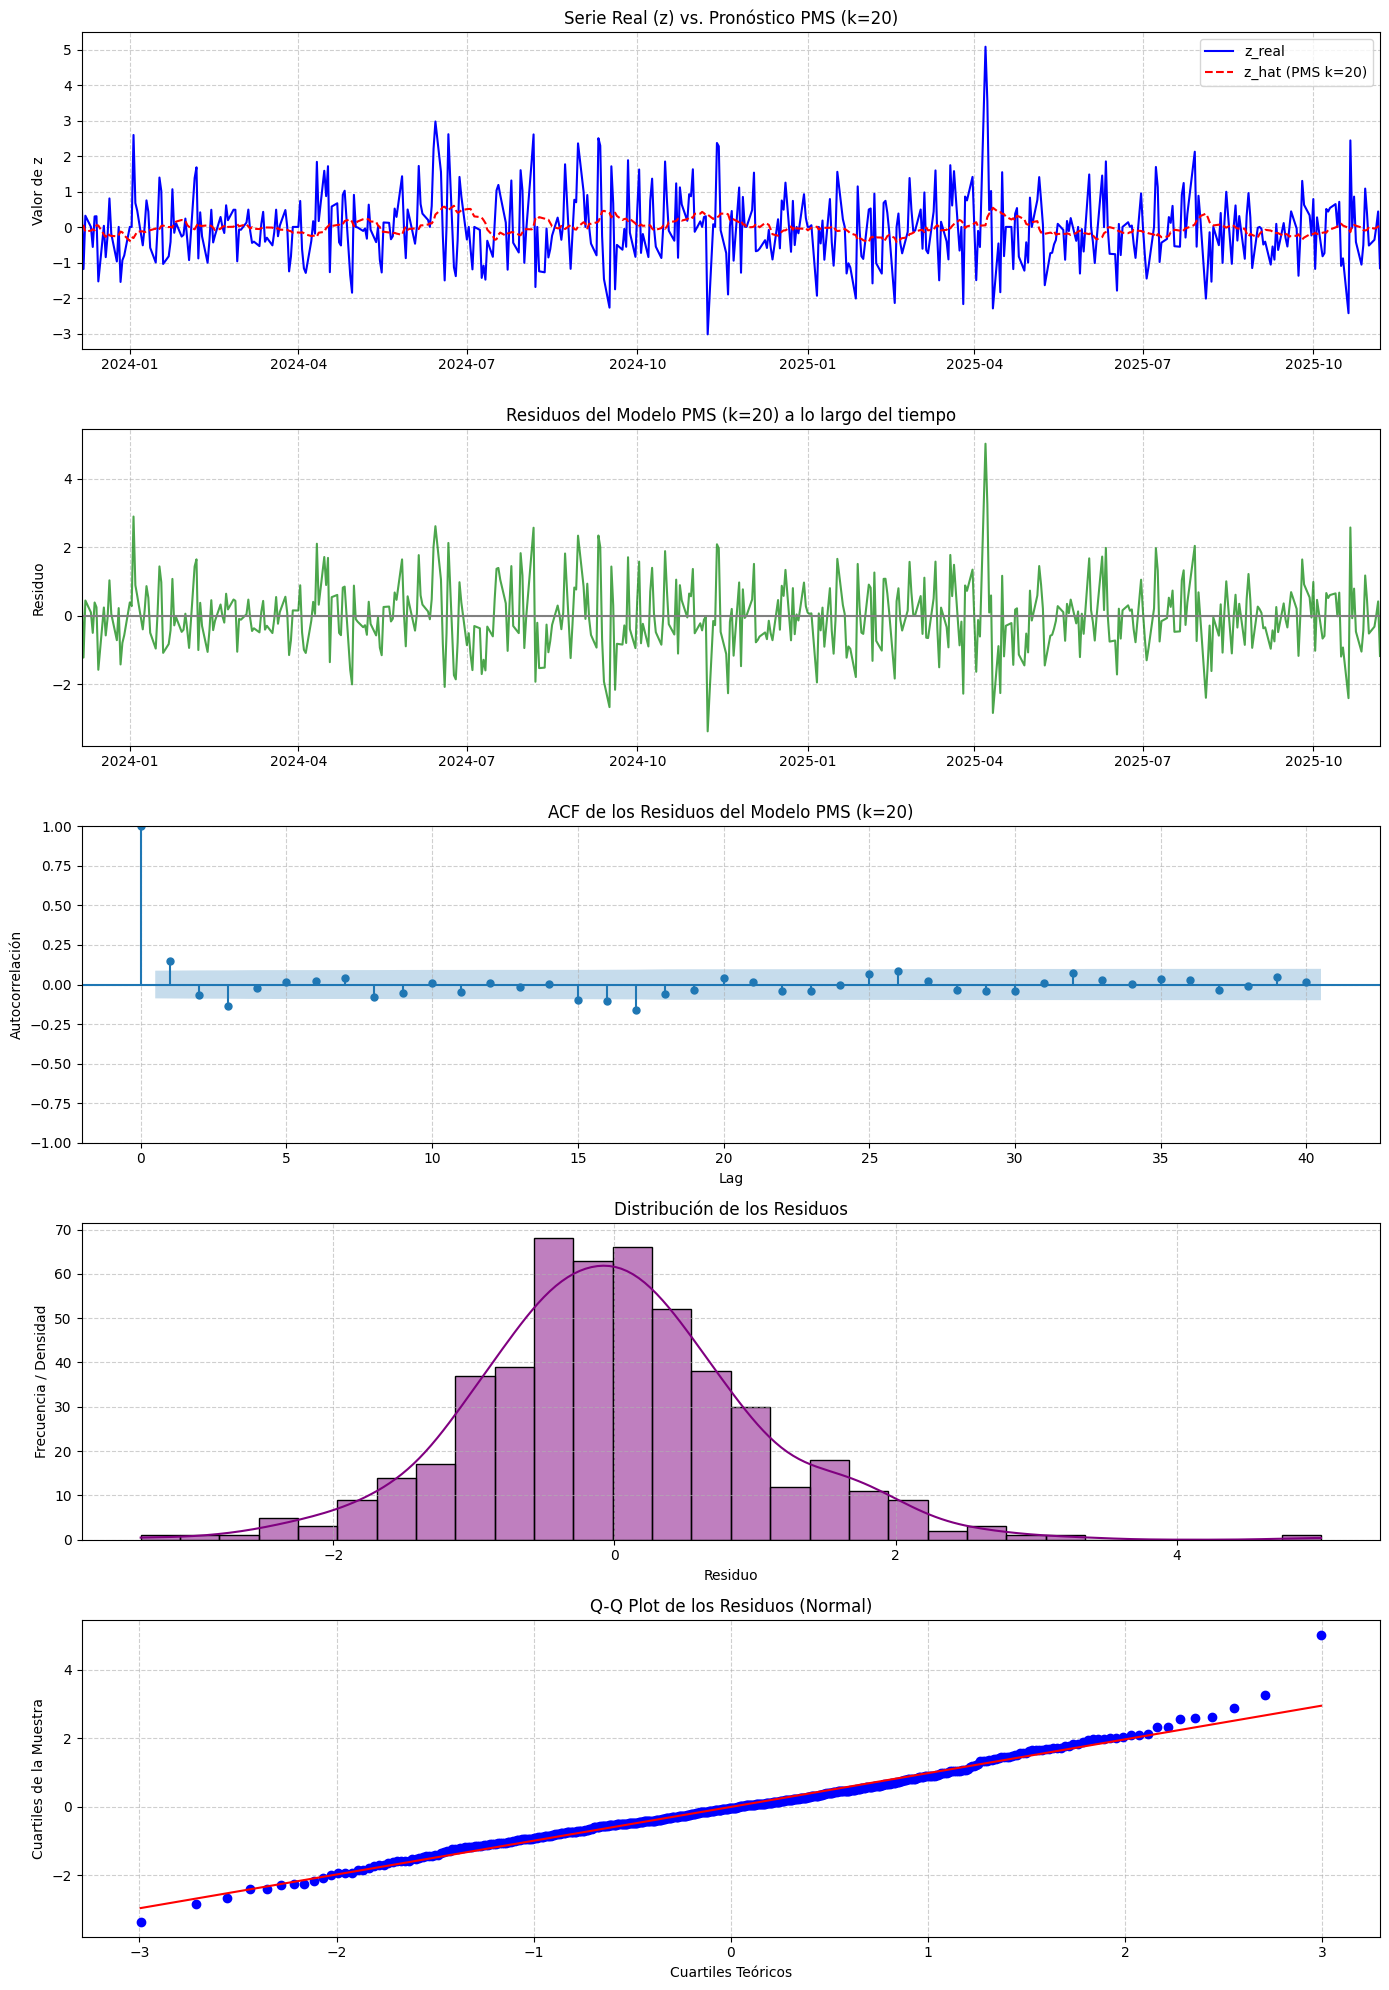


--- Interpretación Básica de los Residuos ---
La media de los residuos (deseablemente cercana a cero) indica la ausencia de sesgo. La desviación estándar es una medida de la variabilidad de los errores.
La ACF de los residuos (deseablemente dentro de las bandas de confianza) indica si hay información temporal no capturada por el modelo.
El histograma y el Q-Q plot permiten una inspección visual de la forma de la distribución de los residuos. Un patrón lineal en el Q-Q plot sugiere normalidad.
El test de Shapiro-Wilk proporciona una prueba estadística formal de normalidad. Un p-value > 0.05 generalmente sugiere que no se puede rechazar la hipótesis de normalidad.


In [ ]:
# CELDA 011
'''
Esta celda realiza un diagnóstico del modelo de Promedio Móvil Simple (PMS)
con una ventana de 20 días sobre la serie 'z'. Para ello:
- Reconstruye el modelo PMS con la ventana óptima (k=20).
- Calcula la serie de residuos (diferencia entre valor real y pronóstico).
- Realiza un diagnóstico básico de los residuos, incluyendo su media, desviación estándar,
  gráficos de evolución y su función de autocorrelación (ACF).
- Además, analiza la distribución de los residuales, verificando visualmente y estadísticamente
  si se aproximan a una distribución normal (histograma, Q-Q plot, test de Shapiro-Wilk).
'''

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import pandas as pd
import os
import seaborn as sns # Para histogramas y KDE
from scipy import stats # Para el test de Shapiro-Wilk y Q-Q plot

print("--- Diagnóstico del Modelo de Promedio Móvil Simple (PMS) con Ventana 20 ---")

# Volver a construir la serie z_series
print("Preparando la serie 'z' para el diagnóstico...")
data_univar = preparar_dataset(['z'])
z_series = data_univar['z']

# Definir k = 20 (la ventana que resultó con menor RMSE en CELDA 010)
k = 20
print(f"Usando ventana k = {k} para el pronóstico PMS.")

# Construir la serie de pronóstico PMS
# El .shift(1) asegura que el pronóstico para un día se basa únicamente en datos pasados.
z_hat = z_series.rolling(window=k).mean().shift(1)

# Crear un DataFrame llamado pms20_df con z_real y z_hat
pms20_df = pd.DataFrame({'z_real': z_series, 'z_hat': z_hat})

# Eliminar filas con NaN en alguna de las dos columnas para asegurar datos completos
pms20_df = pms20_df.dropna()
print(f"DataFrame pms20_df creado con {pms20_df.shape[0]} observaciones después de eliminar NaNs.")

# Calcular la serie de residuos
pms20_df['resid'] = pms20_df['z_real'] - pms20_df['z_hat']

print("\n--- Estadísticas de los Residuos ---")
# Mostrar la media y la desviación estándar de los residuos
media_residuos = pms20_df['resid'].mean()
desv_std_residuos = pms20_df['resid'].std()
print(f"Media de los residuos: {media_residuos:.4f}")
print(f"Desviación estándar de los residuos: {desv_std_residuos:.4f}")

print("\n--- Análisis de Normalidad de los Residuos ---")
# Test de Shapiro-Wilk para normalidad
shapiro_test = stats.shapiro(pms20_df['resid'])
print(f"Estadístico Shapiro-Wilk: {shapiro_test.statistic:.4f}, p-value: {shapiro_test.pvalue:.4f}")
if shapiro_test.pvalue > 0.05:
    print("\t(No se puede rechazar la hipótesis nula de normalidad de los residuos a un nivel de significancia del 5%.)")
else:
    print("\t(Se rechaza la hipótesis nula de normalidad de los residuos a un nivel de significancia del 5%.)")

print("\n--- Visualización del Diagnóstico ---")
# Crear una figura con 5 subgráficos
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 20), sharex=False) # sharex=False para control individual de ejes X

# Obtener los límites de fecha del DataFrame para el eje X (para los plots de serie de tiempo)
xmin = pms20_df.index.min()
xmax = pms20_df.index.max()

# Subplot 1: z_real y z_hat en el tiempo
axes[0].plot(pms20_df.index, pms20_df['z_real'], label='z_real', color='blue')
axes[0].plot(pms20_df.index, pms20_df['z_hat'], label='z_hat (PMS k=20)', color='red', linestyle='--')
axes[0].set_title('Serie Real (z) vs. Pronóstico PMS (k=20)')
axes[0].set_ylabel('Valor de z')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xlim(xmin, xmax) # Establecer los límites del eje X

# Subplot 2: Residuos en el tiempo
axes[1].plot(pms20_df.index, pms20_df['resid'], label='Residuos', color='green', alpha=0.7)
axes[1].axhline(0, color='gray', linestyle='-') # Línea en 0 para referencia
axes[1].set_title('Residuos del Modelo PMS (k=20) a lo largo del tiempo')
axes[1].set_ylabel('Residuo')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xlim(xmin, xmax) # Establecer los límites del eje X

# Subplot 3: ACF de los residuos
plot_acf(pms20_df['resid'], lags=40, ax=axes[2], title='ACF de los Residuos del Modelo PMS (k=20)')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('Autocorrelación')
axes[2].grid(True, linestyle='--', alpha=0.6)
# REMOVIDO: axes[2].set_xlim(xmin, xmax) para permitir que plot_acf maneje su propio eje X de lags.

# Subplot 4: Histograma y KDE de los residuos
sns.histplot(pms20_df['resid'], kde=True, ax=axes[3], color='purple')
axes[3].set_title('Distribución de los Residuos')
axes[3].set_xlabel('Residuo')
axes[3].set_ylabel('Frecuencia / Densidad')
axes[3].grid(True, linestyle='--', alpha=0.6)

# Subplot 5: Q-Q plot de los residuos
stats.probplot(pms20_df['resid'], dist="norm", plot=axes[4])
axes[4].set_title('Q-Q Plot de los Residuos (Normal)')
axes[4].set_xlabel('Cuartiles Teóricos')
axes[4].set_ylabel('Cuartiles de la Muestra')
axes[4].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ajustar automáticamente los parámetros de la subtrama

# Guardar la figura en la carpeta figuras ANTES de mostrarla
file_path_diagnostico = os.path.join(figuras, "diagnostico_pms20_completo.png")
plt.savefig(file_path_diagnostico)
print(f"Figura de diagnóstico completa guardada en: {file_path_diagnostico}") # Indicando el nombre del archivo generado

plt.show() # Mostrar la figura
plt.close(fig) # CERRAR la figura explícitamente después de mostrarla

print("\n--- Interpretación Básica de los Residuos ---")
print("La media de los residuos (deseablemente cercana a cero) indica la ausencia de sesgo. La desviación estándar es una medida de la variabilidad de los errores.")
print("La ACF de los residuos (deseablemente dentro de las bandas de confianza) indica si hay información temporal no capturada por el modelo.")
print("El histograma y el Q-Q plot permiten una inspección visual de la forma de la distribución de los residuos. Un patrón lineal en el Q-Q plot sugiere normalidad.")
print("El test de Shapiro-Wilk proporciona una prueba estadística formal de normalidad. Un p-value > 0.05 generalmente sugiere que no se puede rechazar la hipótesis de normalidad.")

In [ ]:
# CELDA 012
'''
Esta celda ajusta y evalúa un modelo de Suavizado Exponencial Simple (SES) sobre la serie 'z'.

El proceso incluye:
- Ajustar el modelo SES a la serie 'z' utilizando la función 'preparar_dataset'.
- Obtener los pronósticos 'in-sample' generados por el modelo.
- Calcular métricas de error clave como el Error Absoluto Medio (MAE) y la Raíz del Error Cuadrático Medio (RMSE).
- Guardar un DataFrame con estas métricas para diagnósticos y comparaciones posteriores.
'''

import numpy as np
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os
import pandas as pd # Asegurarse de que pandas esté importado

print("--- Preparando la serie univariada 'z' para el modelado SES ---")
# Preparar la serie univariada de trabajo
data_univar = preparar_dataset(['z'])
z_series = data_univar['z']

# Imprimir cuántas observaciones tiene z_series y el rango de fechas
print(f"Serie 'z_series' creada con {len(z_series)} observaciones.")
print(f"Rango de fechas: Desde {z_series.index.min().strftime('%Y-%m-%d')} hasta {z_series.index.max().strftime('%Y-%m-%d')}")

print("\n--- Ajustando el Modelo de Suavizado Exponencial Simple (SES) ---")
# Crear el objeto del modelo SES
ses_model = SimpleExpSmoothing(z_series, initialization_method="estimated")

# Ajustar el modelo dejando que estime automáticamente el parámetro de suavizado (alpha)
ses_fit = ses_model.fit(optimized=True)

# Imprimir el valor estimado de alpha
print(f"Valor estimado del parámetro de suavizado alpha: {ses_fit.params['smoothing_level']:.4f}")

print("\n--- Obteniendo pronósticos in-sample y calculando métricas ---")
# Obtener los pronósticos in-sample
z_hat_ses = ses_fit.fittedvalues

# Crear un DataFrame ses_df con las columnas z_real y z_hat
ses_df = pd.DataFrame({'z_real': z_series, 'z_hat': z_hat_ses})

# Eliminar filas con NaN si las hubiera (aunque fittedvalues no debería generarlos al inicio)
ses_df = ses_df.dropna()
print(f"DataFrame ses_df creado con {ses_df.shape[0]} observaciones después de eliminar NaNs.")

# Calcular la serie de residuos
ses_df['resid'] = ses_df['z_real'] - ses_df['z_hat']

# Calcular MAE y RMSE
mae_ses = mean_absolute_error(ses_df['z_real'], ses_df['z_hat'])
rmse_ses = np.sqrt(mean_squared_error(ses_df['z_real'], ses_df['z_hat']))

# Imprimir MAE y RMSE
print(f"MAE del modelo SES: {mae_ses:.4f}")
print(f"RMSE del modelo SES: {rmse_ses:.4f}")

print("\n--- Resumen rápido del DataFrame de pronósticos SES ---")
# Mostrar un resumen rápido de ses_df
display(ses_df.head())

print("\n--- Guardando resultados del modelo SES ---")
# Guardar la tabla con las métricas en la carpeta outputs
resultados_ses = pd.DataFrame({
    'modelo': ['SES'],
    'alpha': [ses_fit.params['smoothing_level']],
    'MAE': [mae_ses],
    'RMSE': [rmse_ses]
})

file_path_resultados = os.path.join(outputs, "resultados_ses.csv")
resultados_ses.to_csv(file_path_resultados, index=False)
print(f"Tabla de resultados del modelo SES guardada en: {file_path_resultados}") # Documentar los resultados

--- Preparando la serie univariada 'z' para el modelado SES ---
Preparando dataset con las columnas: ['z']
Serie 'z_series' creada con 522 observaciones.
Rango de fechas: Desde 2023-11-08 hasta 2025-11-06

--- Ajustando el Modelo de Suavizado Exponencial Simple (SES) ---
Valor estimado del parámetro de suavizado alpha: 0.0000

--- Obteniendo pronósticos in-sample y calculando métricas ---
DataFrame ses_df creado con 522 observaciones después de eliminar NaNs.
MAE del modelo SES: 0.7397
RMSE del modelo SES: 0.9990

--- Resumen rápido del DataFrame de pronósticos SES ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


,z_real,z_hat,resid
date,,,
2023-11-08,1.064436,3.788096e-08,1.064436
2023-11-09,2.147542,5.374230e-08,2.147542
2023-11-10,-0.302473,8.574316e-08,-0.302473
2023-11-13,-0.686279,8.123596e-08,-0.686279
2023-11-14,0.009148,7.100961e-08,0.009148



--- Guardando resultados del modelo SES ---
Tabla de resultados del modelo SES guardada en: /content/t10drive/MyDrive/taller10/outputs/resultados_ses.csv


--- Diagnóstico del Modelo de Suavizado Exponencial Simple (SES) ---
Número de observaciones en los residuos: 522
Media de los residuos: -0.0000
Desviación estándar de los residuos: 1.0000

--- Visualización Completa del Diagnóstico ---
Figura de diagnóstico completa guardada en: /content/t10drive/MyDrive/taller10/outputs/figuras/diagnostico_ses_completo.png


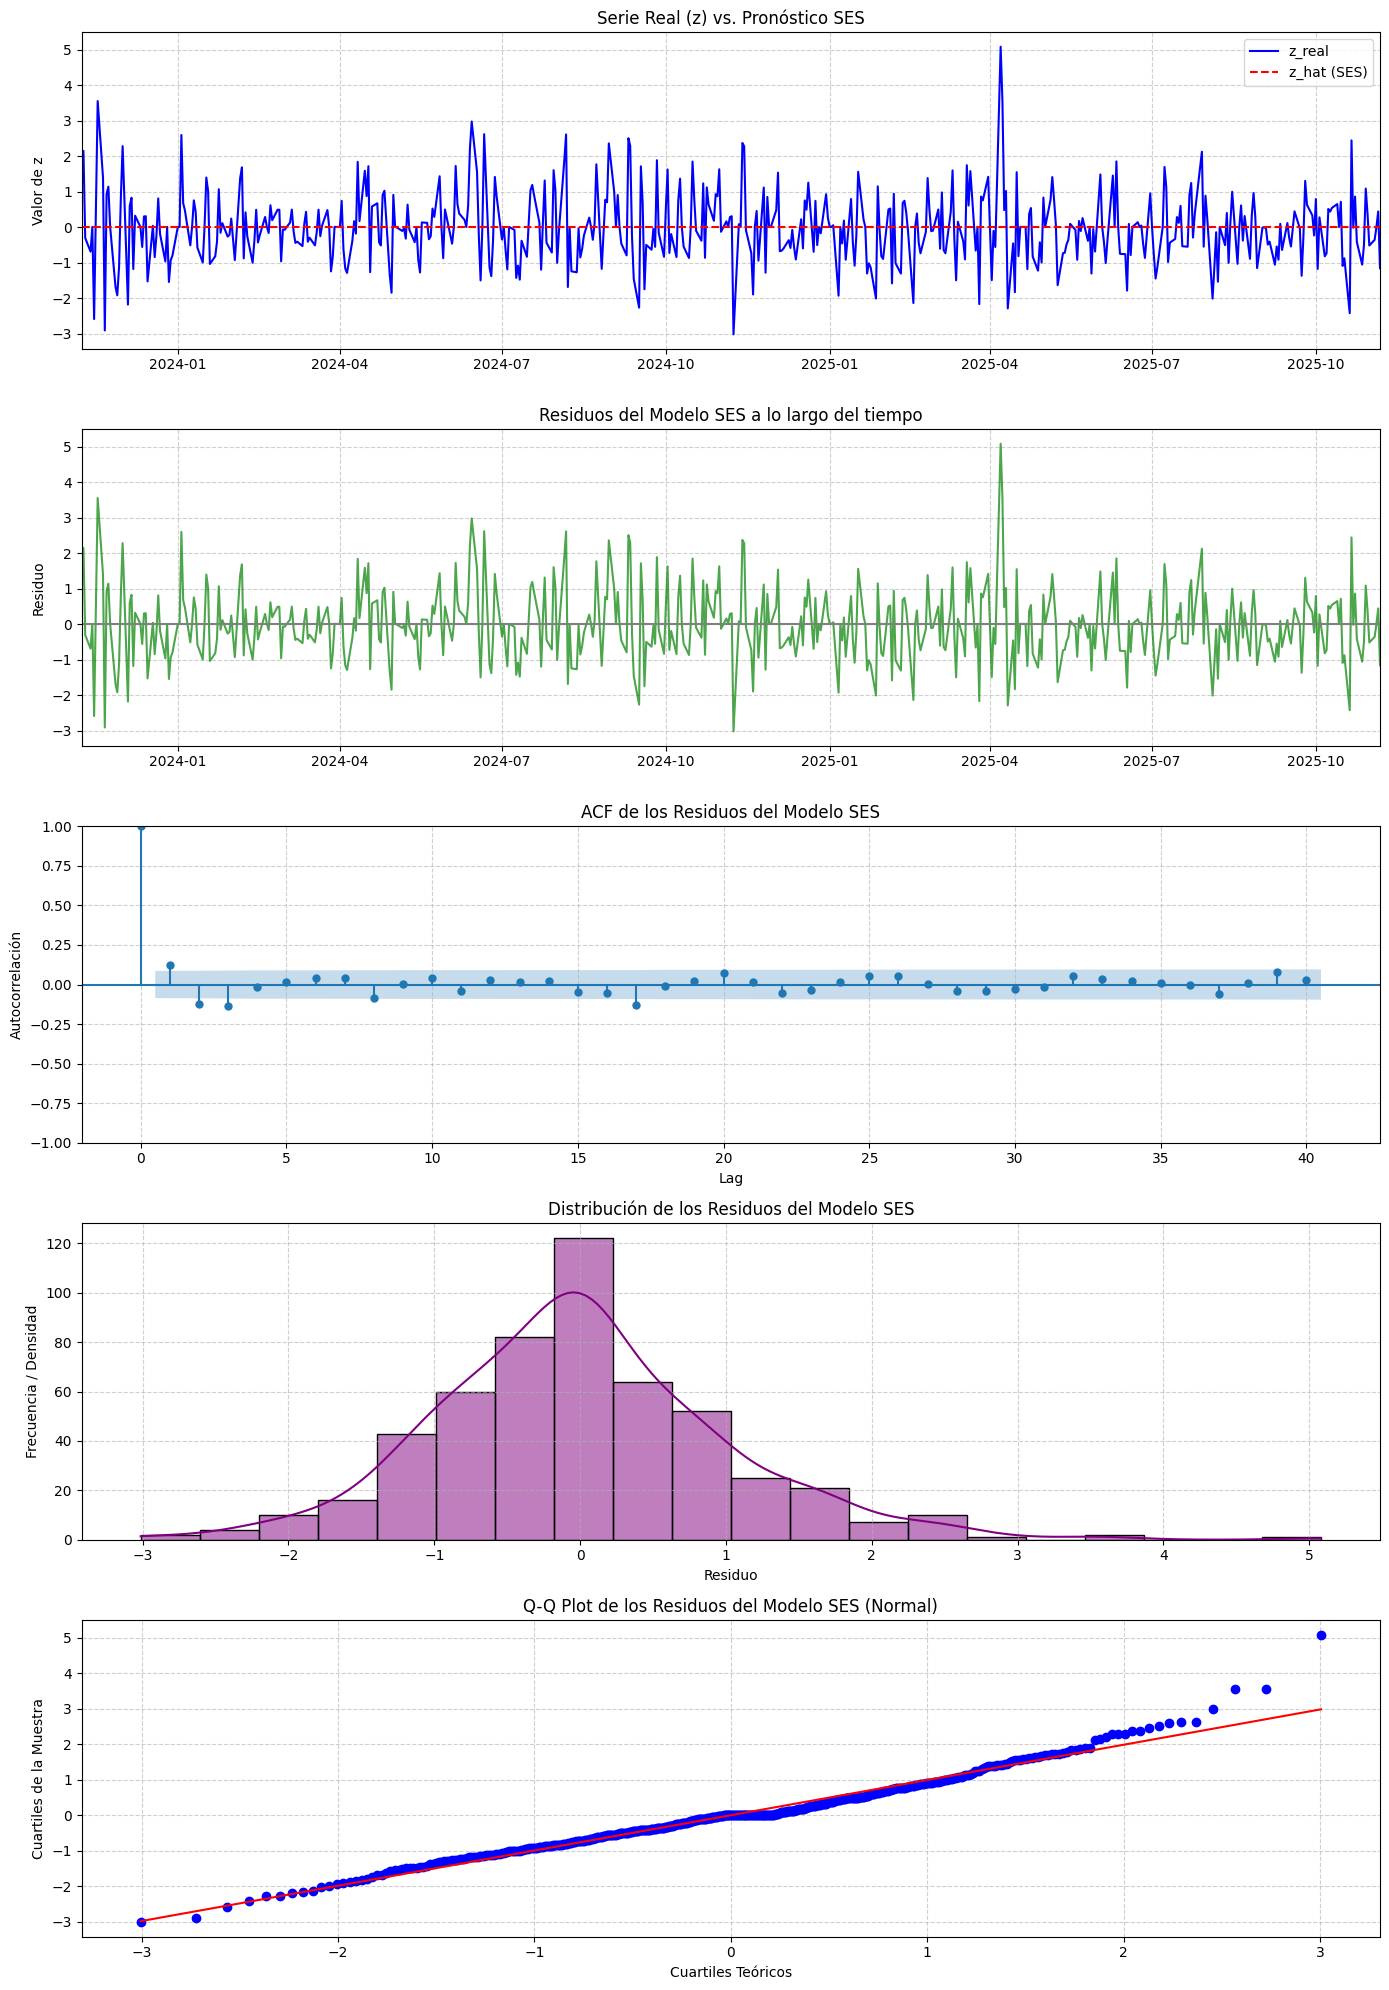


--- Test de Normalidad de Jarque-Bera ---
Estadístico Jarque-Bera: 85.9287, p-value: 0.0000
Hay evidencia para rechazar la hipótesis nula de normalidad de los residuos (p-value <= 0.05).


In [ ]:
# CELDA 013
'''
Esta celda realiza un diagnóstico exhaustivo del modelo de Suavizado Exponencial Simple (SES).
Se enfoca en evaluar el ajuste del modelo, la serie de residuos, la autocorrelación de estos
y su distribución, incluyendo un análisis de normalidad mediante gráficos (histograma, Q-Q plot)
y una prueba estadística (Jarque-Bera).
'''

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import os
import pandas as pd
import numpy as np
import seaborn as sns # Para histogramas y KDE
from scipy import stats # Para Q-Q plot (probplot) y test de Jarque-Bera

print("--- Diagnóstico del Modelo de Suavizado Exponencial Simple (SES) ---")

# Desde ses_df toma z_real, z_hat y resid
# Asumiendo que ses_df ya está cargado en memoria desde CELDA 012
z_real = ses_df['z_real']
z_hat = ses_df['z_hat']
resid = ses_df['resid']

# Imprime cuántas observaciones tiene resid, su media y su desviación estándar.
print(f"Número de observaciones en los residuos: {len(resid)}")
print(f"Media de los residuos: {resid.mean():.4f}")
print(f"Desviación estándar de los residuos: {resid.std():.4f}")

print("\n--- Visualización Completa del Diagnóstico ---")
# Crea una única figura con 5 subgráficos en columna (5 filas, 1 columna), con control independiente del eje X:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 20), sharex=False) # sharex=False para control individual de ejes X

# Obtener los límites de fecha del DataFrame para el eje X
xmin = z_real.index.min()
xmax = z_real.index.max()

# Subplot 1: z_real (azul) y z_hat (rojo punteado) vs tiempo
axes[0].plot(z_real.index, z_real, label='z_real', color='blue')
axes[0].plot(z_real.index, z_hat, label='z_hat (SES)', color='red', linestyle='--')
axes[0].set_title('Serie Real (z) vs. Pronóstico SES')
axes[0].set_ylabel('Valor de z')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xlim(xmin, xmax)

# Subplot 2: resid vs tiempo
axes[1].plot(resid.index, resid, label='Residuos', color='green', alpha=0.7)
axes[1].axhline(0, color='gray', linestyle='-')
axes[1].set_title('Residuos del Modelo SES a lo largo del tiempo')
axes[1].set_ylabel('Residuo')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xlim(xmin, xmax)

# Subplot 3: ACF de resid con plot_acf
plot_acf(resid, lags=40, ax=axes[2], title='ACF de los Residuos del Modelo SES')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('Autocorrelación')
axes[2].grid(True, linestyle='--', alpha=0.6)
# REMOVIDO: axes[2].set_xlim(xmin, xmax) para permitir que plot_acf maneje su propio eje X de lags.

# Subplot 4: histograma de resid (bins=20)
sns.histplot(resid, bins=20, kde=True, ax=axes[3], color='purple')
axes[3].set_title('Distribución de los Residuos del Modelo SES')
axes[3].set_xlabel('Residuo')
axes[3].set_ylabel('Frecuencia / Densidad')
axes[3].grid(True, linestyle='--', alpha=0.6)

# Subplot 5: Q-Q plot de resid frente a la normal (probplot)
stats.probplot(resid, dist="norm", plot=axes[4])
axes[4].set_title('Q-Q Plot de los Residuos del Modelo SES (Normal)')
axes[4].set_xlabel('Cuartiles Teóricos')
axes[4].set_ylabel('Cuartiles de la Muestra')
axes[4].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ajustar automáticamente los parámetros de la subtrama

# Guardar la figura ANTES de mostrarla
file_path_diagnostico_ses = os.path.join(figuras, "diagnostico_ses_completo.png") # Cambiar nombre de archivo
plt.savefig(file_path_diagnostico_ses)
print(f"Figura de diagnóstico completa guardada en: {file_path_diagnostico_ses}")

plt.show() # Mostrar la figura
plt.close(fig) # CERRAR la figura explícitamente

# Aplica jarque_bera a resid
print("\n--- Test de Normalidad de Jarque-Bera ---")
jb_test = stats.jarque_bera(resid)
print(f"Estadístico Jarque-Bera: {jb_test.statistic:.4f}, p-value: {jb_test.pvalue:.4f}")

# Imprime un mensaje corto basado en el p-valor
if jb_test.pvalue > 0.05:
    print("No se puede rechazar la hipótesis nula de normalidad de los residuos (p-value > 0.05).")
else:
    print("Hay evidencia para rechazar la hipótesis nula de normalidad de los residuos (p-value <= 0.05).")

In [ ]:
# CELDA 014
'''
Esta celda ajusta un modelo ETS (Error, Trend, Seasonal) sin tendencia ni estacionalidad
sobre la serie 'z', obtiene pronósticos in-sample y calcula métricas de error.
Esencialmente, este modelo es equivalente a un Suavizado Exponencial Simple (SES).
'''

import numpy as np
from statsmodels.tsa.api import ExponentialSmoothing # Usamos la API de statsmodels
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os
import pandas as pd # Asegurarse de que pandas esté importado

print("--- Preparando la serie univariada 'z' para el modelado ETS --- ")
# Usar la función preparar_dataset para crear data_univar y definir z_series
data_univar = preparar_dataset(['z'])
z_series = data_univar['z']

# Imprimir cuántas observaciones tiene z_series y el rango de fechas (mínima y máxima).
print(f"Serie 'z_series' creada con {len(z_series)} observaciones.")
print(f"Rango de fechas: Desde {z_series.index.min().strftime('%Y-%m-%d')} hasta {z_series.index.max().strftime('%Y-%m-%d')}")

print("\n--- Ajustando el Modelo ETS simple (sin tendencia ni estacionalidad) ---")
# Crear y ajustar el modelo ETS simple
# Equivalentemente, un SES es un ETS(A,N,N) - Aditivo de Error, Sin Tendencia, Sin Estacionalidad
modelo = ExponentialSmoothing(z_series, trend=None, seasonal=None, initialization_method="estimated")
ajuste = modelo.fit(optimized=True)

# Imprimir los parámetros estimados relevantes (por ejemplo el nivel / smoothing_level).
print(f"Valor estimado del parámetro de suavizado (alpha / smoothing_level): {ajuste.params['smoothing_level']:.4f}")

print("\n--- Obteniendo pronósticos in-sample y calculando métricas ---")
# Obtener los pronósticos in-sample
z_hat_ets = ajuste.fittedvalues

# Crear un DataFrame ets_df con las columnas z_real y z_hat
ets_df = pd.DataFrame({
    'z_real': z_series,
    'z_hat': z_hat_ets
})

# Eliminar filas con NaN si las hubiera (aunque fittedvalues no debería generarlos)
ets_df = ets_df.dropna()
print(f"DataFrame ets_df creado con {ets_df.shape[0]} observaciones después de eliminar NaNs.")

# Calcular la columna de residuos
ets_df['resid'] = ets_df['z_real'] - ets_df['z_hat']

# Calcular MAE y RMSE para el modelo ETS
mae_ets = mean_absolute_error(ets_df['z_real'], ets_df['z_hat'])
rmse_ets = np.sqrt(mean_squared_error(ets_df['z_real'], ets_df['z_hat']))

# Mostrar MAE y RMSE con 4 decimales.
print(f"MAE del modelo ETS: {mae_ets:.4f}")
print(f"RMSE del modelo ETS: {rmse_ets:.4f}")

print("\n--- Resumen r\u00E1pido del DataFrame de pron\u00F3sticos ETS ---")
# Mostrar ets_df.head() para ver z_real, z_hat y resid.
display(ets_df.head())

print("\n--- Guardando resultados del modelo ETS ---")
# Guardar una pequeña tabla de resultados en la carpeta outputs
resultados_ets = pd.DataFrame({
    'modelo': ['ETS_simple'],
    'alpha': [ajuste.params['smoothing_level']],
    'MAE': [mae_ets],
    'RMSE': [rmse_ets]
})

file_path_resultados_ets = os.path.join(outputs, "resultados_ets.csv")
resultados_ets.to_csv(file_path_resultados_ets, index=False)
print(f"Tabla de resultados del modelo ETS guardada en: {file_path_resultados_ets}")
# Comentario: El DataFrame 'ets_df' se usará posteriormente para realizar el diagnóstico y el análisis de normalidad de los residuos, similar a lo hecho con los modelos PMS y SES.

--- Preparando la serie univariada 'z' para el modelado ETS --- 
Preparando dataset con las columnas: ['z']
Serie 'z_series' creada con 522 observaciones.
Rango de fechas: Desde 2023-11-08 hasta 2025-11-06

--- Ajustando el Modelo ETS simple (sin tendencia ni estacionalidad) ---
Valor estimado del parámetro de suavizado (alpha / smoothing_level): 0.0000

--- Obteniendo pronósticos in-sample y calculando métricas ---
DataFrame ets_df creado con 522 observaciones después de eliminar NaNs.
MAE del modelo ETS: 0.7397
RMSE del modelo ETS: 0.9990

--- Resumen rápido del DataFrame de pronósticos ETS ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


,z_real,z_hat,resid
date,,,
2023-11-08,1.064436,3.788096e-08,1.064436
2023-11-09,2.147542,5.374230e-08,2.147542
2023-11-10,-0.302473,8.574316e-08,-0.302473
2023-11-13,-0.686279,8.123596e-08,-0.686279
2023-11-14,0.009148,7.100961e-08,0.009148



--- Guardando resultados del modelo ETS ---
Tabla de resultados del modelo ETS guardada en: /content/t10drive/MyDrive/taller10/outputs/resultados_ets.csv


--- Diagnóstico del Modelo ETS Simple ---
Número de observaciones en los residuos: 522
Media de los residuos: -0.0000
Desviación estándar de los residuos: 1.0000

--- Visualización Completa del Diagnóstico ---
Figura de diagnóstico completo del modelo ETS guardada en: /content/t10drive/MyDrive/taller10/outputs/figuras/diagnostico_completo_ets.png


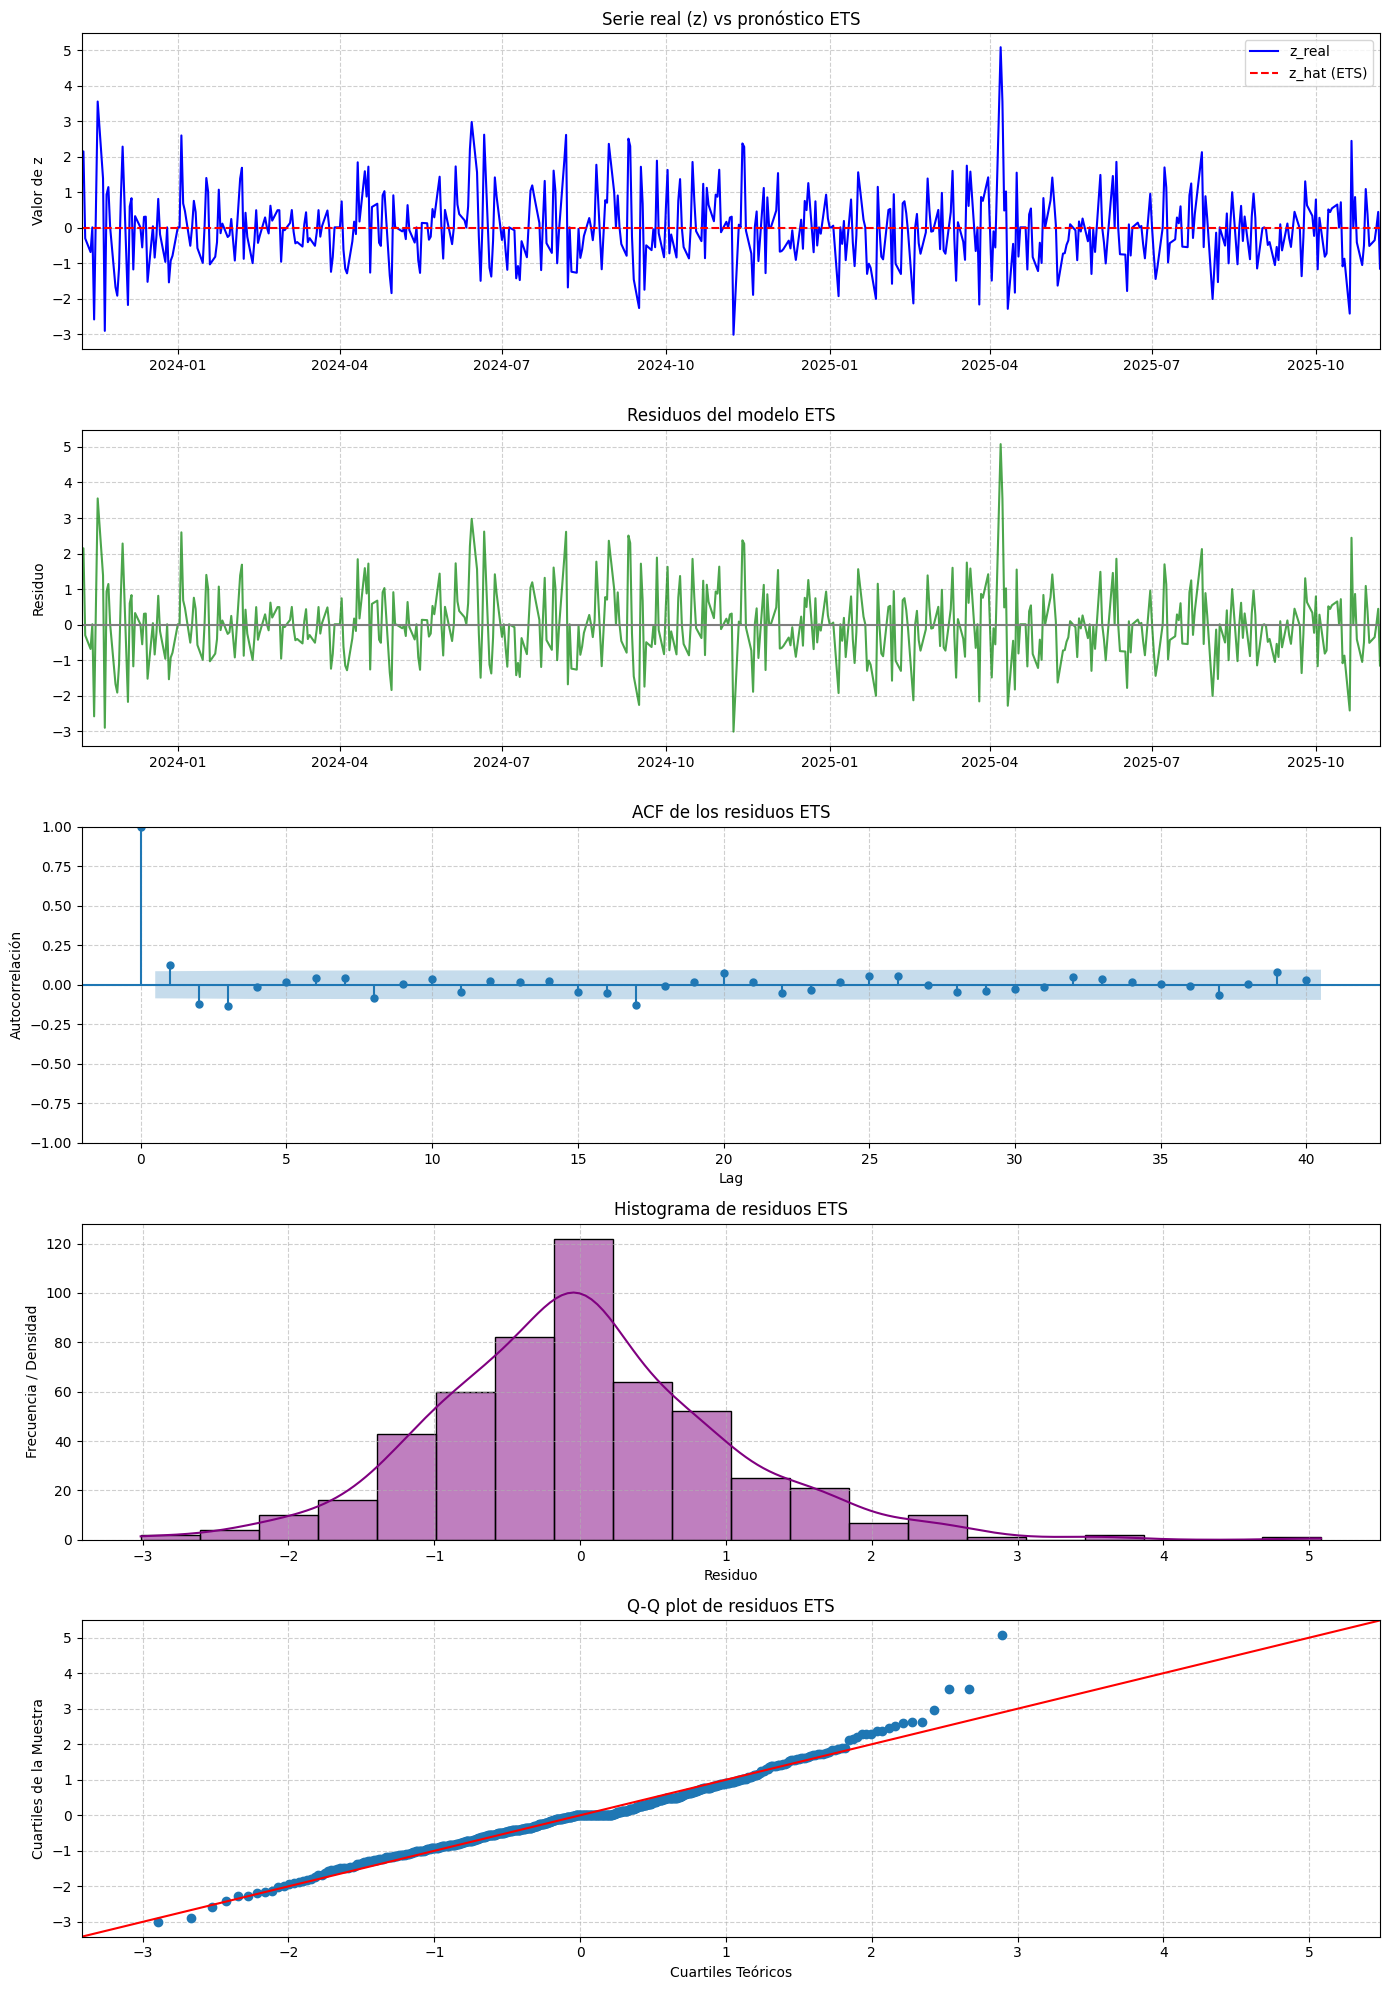


--- Test de Normalidad de Shapiro-Wilk ---
Estadístico Shapiro-Wilk: 0.9780, p-value: 0.0000
Hay evidencia de que los residuos del modelo ETS no siguen una distribución normal (p-value <= 0.05).


In [ ]:
# CELDA 015
'''
Esta celda diagnostica el modelo ETS simple:
- Compara la serie real (z) con el pronóstico generado por el modelo.
- Analiza el comportamiento de los residuos (errores del modelo) a lo largo del tiempo.
- Revisa la autocorrelación de los residuos para detectar patrones no capturados.
- Evalúa la normalidad de la distribución de los residuos mediante gráficos (histograma, Q-Q plot)
  y el test estadístico de Shapiro-Wilk.
'''

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot # Para el Q-Q plot
from scipy.stats import shapiro # Para el test de Shapiro-Wilk
import os
import pandas as pd # Asegurarse de que pandas esté importado
import numpy as np # Para funciones numéricas generales
import seaborn as sns # Para mejorar histogramas con KDE

print("--- Diagnóstico del Modelo ETS Simple ---")

# Desde ets_df, toma z_real, z_hat y resid
# Asumiendo que ets_df ya está cargado en memoria desde CELDA 014
z_real = ets_df['z_real']
z_hat = ets_df['z_hat']
resid = ets_df['resid']

# Imprime cuántas observaciones tiene resid, su media y su desviación estándar.
print(f"Número de observaciones en los residuos: {len(resid)}")
print(f"Media de los residuos: {resid.mean():.4f}")
print(f"Desviación estándar de los residuos: {resid.std():.4f}")

print("\n--- Visualización Completa del Diagnóstico ---")
# Crea una única figura con 5 subgráficos en columna (5 filas, 1 columna), con control independiente del eje X:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 20), sharex=False) # sharex=False para control individual de ejes X

# Obtener los límites de fecha del DataFrame para el eje X
xmin = z_real.index.min()
xmax = z_real.index.max()

# Subplot 1: z_real (azul) y z_hat (rojo punteado) vs tiempo
axes[0].plot(z_real.index, z_real, label='z_real', color='blue')
axes[0].plot(z_real.index, z_hat, label='z_hat (ETS)', color='red', linestyle='--')
axes[0].set_title('Serie real (z) vs pronóstico ETS')
axes[0].set_ylabel('Valor de z')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xlim(xmin, xmax) # Establecer los límites del eje X

# Subplot 2: resid vs tiempo
axes[1].plot(resid.index, resid, label='Residuos', color='green', alpha=0.7)
axes[1].axhline(0, color='gray', linestyle='-') # Línea en 0 para referencia
axes[1].set_title('Residuos del modelo ETS')
axes[1].set_ylabel('Residuo')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xlim(xmin, xmax) # Establecer los límites del eje X

# Subplot 3: ACF de resid usando plot_acf
plot_acf(resid, lags=40, ax=axes[2], title='ACF de los residuos ETS')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('Autocorrelación')
axes[2].grid(True, linestyle='--', alpha=0.6)
# REMOVIDO: axes[2].set_xlim(xmin, xmax) para permitir que plot_acf maneje su propio eje X de lags.

# Subplot 4: histograma de resid
sns.histplot(resid, bins=20, kde=True, ax=axes[3], color='purple')
axes[3].set_title('Histograma de residuos ETS')
axes[3].set_xlabel('Residuo')
axes[3].set_ylabel('Frecuencia / Densidad')
axes[3].grid(True, linestyle='--', alpha=0.6)

# Subplot 5: Q-Q plot de resid frente a la normal usando qqplot con línea de 45 grados
qqplot(resid, line='45', ax=axes[4]) # line='45' añade la línea de referencia diagonal
axes[4].set_title('Q-Q plot de residuos ETS')
axes[4].set_xlabel('Cuartiles Teóricos')
axes[4].set_ylabel('Cuartiles de la Muestra')
axes[4].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ajustar el diseño para evitar superposiciones

# Guardar la figura en la carpeta figuras ANTES de mostrarla
file_path_diagnostico_ets = os.path.join(figuras, "diagnostico_completo_ets.png")
plt.savefig(file_path_diagnostico_ets)
print(f"Figura de diagnóstico completo del modelo ETS guardada en: {file_path_diagnostico_ets}") # Indicando el nombre del archivo generado

plt.show() # Mostrar la figura
plt.close(fig) # CERRAR la figura explícitamente después de mostrarla

print("\n--- Test de Normalidad de Shapiro-Wilk ---")
# Aplica la prueba de Shapiro-Wilk a resid con shapiro.
shapiro_test = shapiro(resid)
print(f"Estadístico Shapiro-Wilk: {shapiro_test.statistic:.4f}, p-value: {shapiro_test.pvalue:.4f}")

# Imprime un mensaje corto interpretando el p-valor
if shapiro_test.pvalue > 0.05:
    print("No se rechaza la normalidad de los residuos del modelo ETS (p-value > 0.05).")
else:
    print("Hay evidencia de que los residuos del modelo ETS no siguen una distribuci\u00F3n normal (p-value <= 0.05).")

In [ ]:
# CELDA 016
'''
Esta celda ajusta modelos AR(p) para p = 1, 2, 3, 4 y 5 usando los rezagos z_lag1…z_lag5 de data_model.
Calcula el Error Absoluto Medio (MAE) y la Raíz del Error Cuadrático Medio (RMSE)
para cada orden p, y elige el mejor orden de modelo AR(p) según el RMSE.
'''

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

print("--- Evaluando modelos Autorregresivos (AR(p)) ---")

# Definir órdenes a evaluar
ordenes = [1, 2, 3, 4, 5]

# Lista para almacenar los resultados de cada modelo AR(p)
resultados_ar = []

# Variables para almacenar el mejor modelo encontrado
mejor_p = None
mejor_rmse = None
ar_best_df = None

# Iterar sobre cada orden p
for p in ordenes:
    print(f"\nAjustando modelo AR({p})...")

    # 1. Definir las columnas para el dataset limpio
    # 'z' es la variable dependiente, y 'z_lag1' hasta 'z_lagp' son las variables independientes.
    cols = ['z'] + [f'z_lag{i}' for i in range(1, p + 1)]

    # 2. Crear un dataset limpio usando la función preparar_dataset
    df_p = preparar_dataset(cols)

    # Si no hay suficientes observaciones después de eliminar NaNs, saltar este orden
    if df_p.empty:
        print(f"Advertencia: No hay suficientes datos para el modelo AR({p}) después de eliminar NaNs.")
        continue

    # 3. Definir la variable dependiente (y) y las variables independientes (X)
    y = df_p['z']
    X = df_p.drop(columns=['z'])

    # 4. Agregar una constante a X para el intercepto del modelo OLS
    X_const = sm.add_constant(X)

    # 5. Ajustar un modelo OLS (Ordinary Least Squares) usando statsmodels
    modelo = sm.OLS(y, X_const)
    ajuste = modelo.fit()

    # 6. Obtener los valores ajustados (pronósticos in-sample)
    y_hat = ajuste.fittedvalues

    # 7. Calcular MAE y RMSE
    mae = mean_absolute_error(y, y_hat)
    rmse = np.sqrt(mean_squared_error(y, y_hat))

    # Imprimir métricas para el orden actual
    print(f"  Orden AR(p={p}): MAE = {mae:.4f}, RMSE = {rmse:.4f}, Observaciones = {len(y)}")

    # 8. Guardar los resultados en la lista
    resultados_ar.append({
        'orden_p': p,
        'n_obs': len(y),
        'MAE': mae,
        'RMSE': rmse
    })

    # 9. Actualizar el mejor modelo si el RMSE actual es menor
    if mejor_rmse is None or rmse < mejor_rmse:
        mejor_rmse = rmse
        mejor_p = p

        # Crear ar_best_df para el diagnóstico posterior del mejor modelo
        ar_best_df = pd.DataFrame({
            'z_real': y,
            'z_hat': y_hat,
            'resid': y - y_hat
        })
        # Asegurarse de que el índice del ar_best_df se mantenga para el diagnóstico temporal
        ar_best_df.index = y.index

# 10. Convertir la lista de resultados a un DataFrame para una mejor visualización
resultados_ar_df = pd.DataFrame(resultados_ar)

print("\n--- Tabla de Resultados de Modelos AR(p) ---")
display(resultados_ar_df)

# 11. Guardar la tabla de resultados en la carpeta outputs
file_path_resultados_ar = os.path.join(outputs, "resultados_ar.csv")
resultados_ar_df.to_csv(file_path_resultados_ar, index=False)
print(f"Tabla de resultados de modelos AR(p) guardada en: {file_path_resultados_ar}")

# 12. Imprimir un mensaje final indicando el mejor orden AR(p) y su RMSE
if mejor_p is not None:
    print(f"\nEl mejor modelo AR(p) encontrado es AR({mejor_p}) con un RMSE de {mejor_rmse:.4f}.")
else:
    print("No se pudo ajustar ningún modelo AR(p).")

# Comentario: El DataFrame 'ar_best_df' contiene los valores reales, pronosticados y residuos
# del mejor modelo AR(p) y está disponible para un diagnóstico de residuos en una celda posterior.

--- Evaluando modelos Autorregresivos (AR(p)) ---

Ajustando modelo AR(1)...
Preparando dataset con las columnas: ['z', 'z_lag1']
  Orden AR(p=1): MAE = 0.7440, RMSE = 0.9909, Observaciones = 521

Ajustando modelo AR(2)...
Preparando dataset con las columnas: ['z', 'z_lag1', 'z_lag2']
  Orden AR(p=2): MAE = 0.7395, RMSE = 0.9782, Observaciones = 520

Ajustando modelo AR(3)...
Preparando dataset con las columnas: ['z', 'z_lag1', 'z_lag2', 'z_lag3']
  Orden AR(p=3): MAE = 0.7380, RMSE = 0.9736, Observaciones = 519

Ajustando modelo AR(4)...
Preparando dataset con las columnas: ['z', 'z_lag1', 'z_lag2', 'z_lag3', 'z_lag4']
  Orden AR(p=4): MAE = 0.7390, RMSE = 0.9745, Observaciones = 518

Ajustando modelo AR(5)...
Preparando dataset con las columnas: ['z', 'z_lag1', 'z_lag2', 'z_lag3', 'z_lag4', 'z_lag5']
  Orden AR(p=5): MAE = 0.7402, RMSE = 0.9753, Observaciones = 517

--- Tabla de Resultados de Modelos AR(p) ---


,orden_p,n_obs,MAE,RMSE
0,1,521,0.744002,0.990929
1,2,520,0.739452,0.978210
2,3,519,0.738029,0.973609
3,4,518,0.738988,0.974476
4,5,517,0.740246,0.975288


Tabla de resultados de modelos AR(p) guardada en: /content/t10drive/MyDrive/taller10/outputs/resultados_ar.csv

El mejor modelo AR(p) encontrado es AR(3) con un RMSE de 0.9736.


--- Diagnóstico del Mejor Modelo AR(p) (AR(3)) ---
Número de observaciones en los residuos: 519
Media de los residuos: 0.0000
Desviación estándar de los residuos: 0.9745

--- Visualización Completa del Diagnóstico ---
Figura de diagnóstico completo del modelo AR(3) guardada en: /content/t10drive/MyDrive/taller10/outputs/figuras/diagnostico_completo_ar3.png


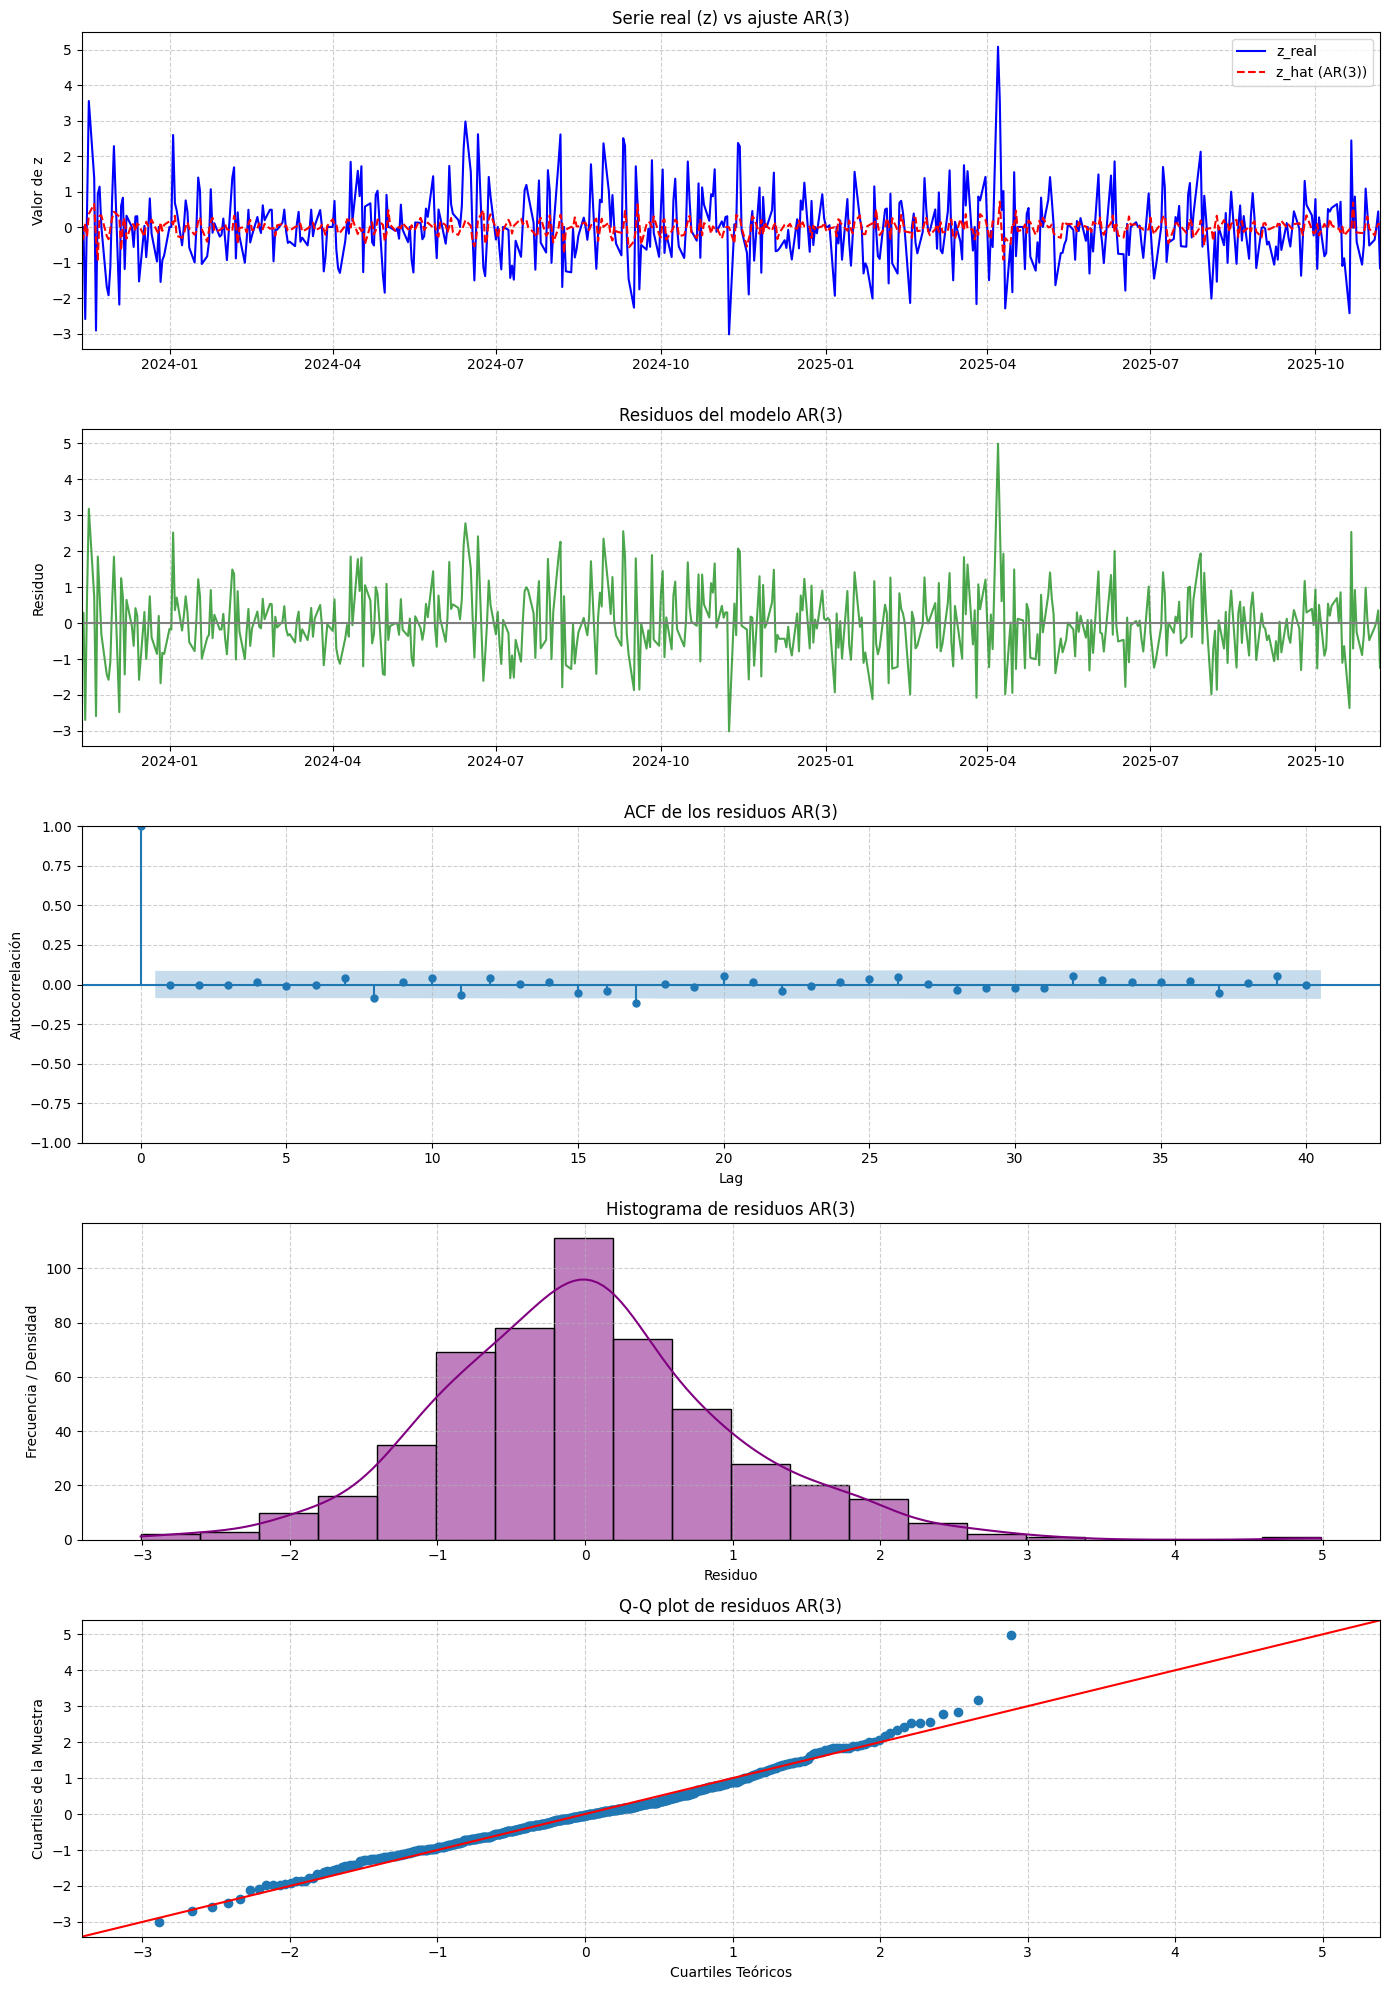


--- Test de Normalidad de Shapiro-Wilk ---
Estadístico Shapiro-Wilk: 0.9842, p-value: 0.0000
Hay evidencia de que los residuos del modelo AR(3) no siguen una distribución normal (p-value <= 0.05).


In [ ]:
# CELDA 017
'''
Esta celda diagnostica el mejor modelo AR(p) (en este caso AR(3)): compara la serie real
con la ajustada, analiza los residuos, su autocorrelación y su normalidad.
Proporciona una visión completa del rendimiento del modelo.
'''

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot # Para el Q-Q plot
from scipy.stats import shapiro # Para el test de Shapiro-Wilk
import os
import pandas as pd # Aunque ya está importado, buena práctica
import numpy as np # Aunque ya está importado, buena práctica
import seaborn as sns # Para mejorar histogramas con KDE

print("--- Diagnóstico del Mejor Modelo AR(p) (AR(3)) ---")

# Desde ar_best_df, extrae z_real, z_hat y resid
# ar_best_df fue generado en CELDA 016 para el mejor modelo AR(p)
z_real = ar_best_df['z_real']
z_hat = ar_best_df['z_hat']
resid = ar_best_df['resid']

# Imprime cuántas observaciones tiene resid, su media y su desviación estándar.
print(f"Número de observaciones en los residuos: {len(resid)}")
print(f"Media de los residuos: {resid.mean():.4f}")
print(f"Desviación estándar de los residuos: {resid.std():.4f}")

print("\n--- Visualización Completa del Diagnóstico ---")
# Crea una única figura con 5 subplots en columna (5 filas, 1 columna), con control independiente del eje X:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 20), sharex=False) # sharex=False para control individual de ejes X

# Obtener los límites de fecha del DataFrame para el eje X (para los plots de serie de tiempo)
xmin = z_real.index.min()
xmax = z_real.index.max()

# Subplot 1: z_real en azul y z_hat en rojo punteado vs tiempo
axes[0].plot(z_real.index, z_real, label='z_real', color='blue')
axes[0].plot(z_real.index, z_hat, label='z_hat (AR(3))', color='red', linestyle='--')
axes[0].set_title('Serie real (z) vs ajuste AR(3)')
axes[0].set_ylabel('Valor de z')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xlim(xmin, xmax) # Establecer los límites del eje X

# Subplot 2: resid vs tiempo
axes[1].plot(resid.index, resid, label='Residuos', color='green', alpha=0.7)
axes[1].axhline(0, color='gray', linestyle='-') # Línea en 0 para referencia
axes[1].set_title('Residuos del modelo AR(3)')
axes[1].set_ylabel('Residuo')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xlim(xmin, xmax) # Establecer los límites del eje X

# Subplot 3: ACF de resid usando plot_acf
plot_acf(resid, lags=40, ax=axes[2], title='ACF de los residuos AR(3)')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('Autocorrelación')
axes[2].grid(True, linestyle='--', alpha=0.6)
# REMOVIDO: axes[2].set_xlim(xmin, xmax) para permitir que plot_acf maneje su propio eje X de lags.

# Subplot 4: histograma de resid (bins=20)
sns.histplot(resid, bins=20, kde=True, ax=axes[3], color='purple')
axes[3].set_title('Histograma de residuos AR(3)')
axes[3].set_xlabel('Residuo')
axes[3].set_ylabel('Frecuencia / Densidad')
axes[3].grid(True, linestyle='--', alpha=0.6)

# Subplot 5: Q-Q plot de resid frente a la normal usando qqplot con línea de 45°
qqplot(resid, line='45', ax=axes[4]) # line='45' añade la línea de referencia diagonal
axes[4].set_title('Q-Q plot de residuos AR(3)')
axes[4].set_xlabel('Cuartiles Teóricos')
axes[4].set_ylabel('Cuartiles de la Muestra')
axes[4].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ajustar el diseño para evitar superposiciones

# Guardar la figura en la carpeta figuras ANTES de mostrarla
file_path_diagnostico_ar3 = os.path.join(figuras, "diagnostico_completo_ar3.png")
plt.savefig(file_path_diagnostico_ar3)
print(f"Figura de diagnóstico completo del modelo AR(3) guardada en: {file_path_diagnostico_ar3}") # Indicando el nombre del archivo generado

plt.show() # Mostrar la figura
plt.close(fig) # CERRAR la figura explícitamente después de mostrarla

print("\n--- Test de Normalidad de Shapiro-Wilk ---")
# Aplica la prueba de Shapiro-Wilk a resid con shapiro.
shapiro_test = shapiro(resid)
print(f"Estadístico Shapiro-Wilk: {shapiro_test.statistic:.4f}, p-value: {shapiro_test.pvalue:.4f}")

# Imprime un mensaje corto interpretando el p-valor
if shapiro_test.pvalue > 0.05:
    print("No se rechaza la normalidad de los residuos del modelo AR(3) (p-value > 0.05).")
else:
    print("Hay evidencia de que los residuos del modelo AR(3) no siguen una distribución normal (p-value <= 0.05).")

In [ ]:
# CELDA 018
'''
Esta celda ajusta un modelo de regresión lineal múltiple para explicar 'z'
usando las variables externas 'oil', 'dol_wg' y 'vix' como regresores contemporáneos.
Se calcularán métricas de error (MAE, RMSE) y el R² para comparar su rendimiento
con los modelos univariados (PMS, SES, ETS, AR(p)) previamente evaluados.
'''

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

print("--- Ajustando Modelo de Regresión Lineal Múltiple ---")

# Usar la función preparar_dataset para crear un DataFrame limpio sin valores nulos
# con las variables necesarias para este modelo de regresión.
df_reg = preparar_dataset(['z', 'oil', 'dol_wg', 'vix'])

print(f"DataFrame para regresión creado con forma: {df_reg.shape}")
print(f"Rango de fechas: Desde {df_reg.index.min().strftime('%Y-%m-%d')} hasta {df_reg.index.max().strftime('%Y-%m-%d')}")

# Definir la variable dependiente (y) y las variables independientes (X)
y = df_reg['z']
X = df_reg[['oil', 'dol_wg', 'vix']]

# Agregar una constante a X para incluir el intercepto en el modelo
X_const = sm.add_constant(X)

# Ajustar un modelo OLS (Ordinary Least Squares) con statsmodels
modelo_reg = sm.OLS(y, X_const)
ajuste_reg = modelo_reg.fit()

print("\n--- Resumen del Modelo de Regresión ---")
# Imprimir un resumen corto: al menos los coeficientes estimados de cada regresor y el R².
print(ajuste_reg.summary2().tables[1]) # Coeficientes
print(f"R-cuadrado (R²): {ajuste_reg.rsquared:.4f}") # R-cuadrado

# Obtener los valores ajustados (pronósticos in-sample)
z_hat_reg = ajuste_reg.fittedvalues

# Crear un DataFrame reg_df con z_real, z_hat y resid
reg_df = pd.DataFrame({
    'z_real': y,
    'z_hat': z_hat_reg,
    'resid': y - z_hat_reg
})

# Calcular MAE y RMSE del modelo de regresión
mae_reg = mean_absolute_error(reg_df['z_real'], reg_df['z_hat'])
rmse_reg = np.sqrt(mean_squared_error(reg_df['z_real'], reg_df['z_hat']))

print("\n--- Métricas de Error del Modelo de Regresión ---")
print(f"MAE del modelo de Regresión: {mae_reg:.4f}")
print(f"RMSE del modelo de Regresión: {rmse_reg:.4f}")
print("Estos resultados se podrán comparar con PMS, SES, ETS y AR(3) para evaluar el rendimiento.")

print("\n--- Vista rápida del DataFrame de pronósticos de Regresión ---")
# Mostrar reg_df.head() para ver z_real, z_hat y resid.
display(reg_df.head())

print("\n--- Guardando resultados del modelo de Regresión ---")
# Guardar una pequeña tabla de resultados en la carpeta outputs
resultados_regresion = pd.DataFrame({
    'modelo': ['Regresion_z_oil_dolwg_vix'],
    'MAE': [mae_reg],
    'RMSE': [rmse_reg],
    'R2': [ajuste_reg.rsquared]
})

file_path_resultados_regresion = os.path.join(outputs, "resultados_regresion_multivariada.csv")
resultados_regresion.to_csv(file_path_resultados_regresion, index=False)
print(f"Tabla de resultados del modelo de Regresión guardada en: {file_path_resultados_regresion}")


--- Ajustando Modelo de Regresión Lineal Múltiple ---
Preparando dataset con las columnas: ['z', 'oil', 'dol_wg', 'vix']
DataFrame para regresión creado con forma: (522, 4)
Rango de fechas: Desde 2023-11-08 hasta 2025-11-06

--- Resumen del Modelo de Regresión ---
           Coef.  Std.Err.         t     P>|t|    [0.025    0.975]
const  -1.648785  2.022269 -0.815314  0.415267 -5.621643  2.324072
oil     0.008015  0.007443  1.076846  0.282050 -0.006607  0.022637
dol_wg  0.004544  0.016933  0.268381  0.788513 -0.028721  0.037809
vix     0.030665  0.010737  2.855901  0.004464  0.009571  0.051759
R-cuadrado (R²): 0.0184

--- Métricas de Error del Modelo de Regresión ---
MAE del modelo de Regresión: 0.7423
RMSE del modelo de Regresión: 0.9898
Estos resultados se podrán comparar con PMS, SES, ETS y AR(3) para evaluar el rendimiento.

--- Vista rápida del DataFrame de pronósticos de Regresión ---


,z_real,z_hat,resid
date,,,
2023-11-08,1.064436,-0.045812,1.110249
2023-11-09,2.147542,-0.016355,2.163897
2023-11-10,-0.302473,-0.038807,-0.263666
2023-11-13,-0.686279,-0.011708,-0.674570
2023-11-14,0.009148,-0.035050,0.044198



--- Guardando resultados del modelo de Regresión ---
Tabla de resultados del modelo de Regresión guardada en: /content/t10drive/MyDrive/taller10/outputs/resultados_regresion_multivariada.csv


--- Diagnóstico del Modelo de Regresión Lineal Múltiple ---
Número de observaciones en los residuos: 522
Media de los residuos: 0.0000
Desviación estándar de los residuos: 0.9908

--- Visualización Completa del Diagnóstico ---
Figura de diagnóstico completo del modelo de Regresión guardada en: /content/t10drive/MyDrive/taller10/outputs/figuras/diagnostico_completo_regresion.png


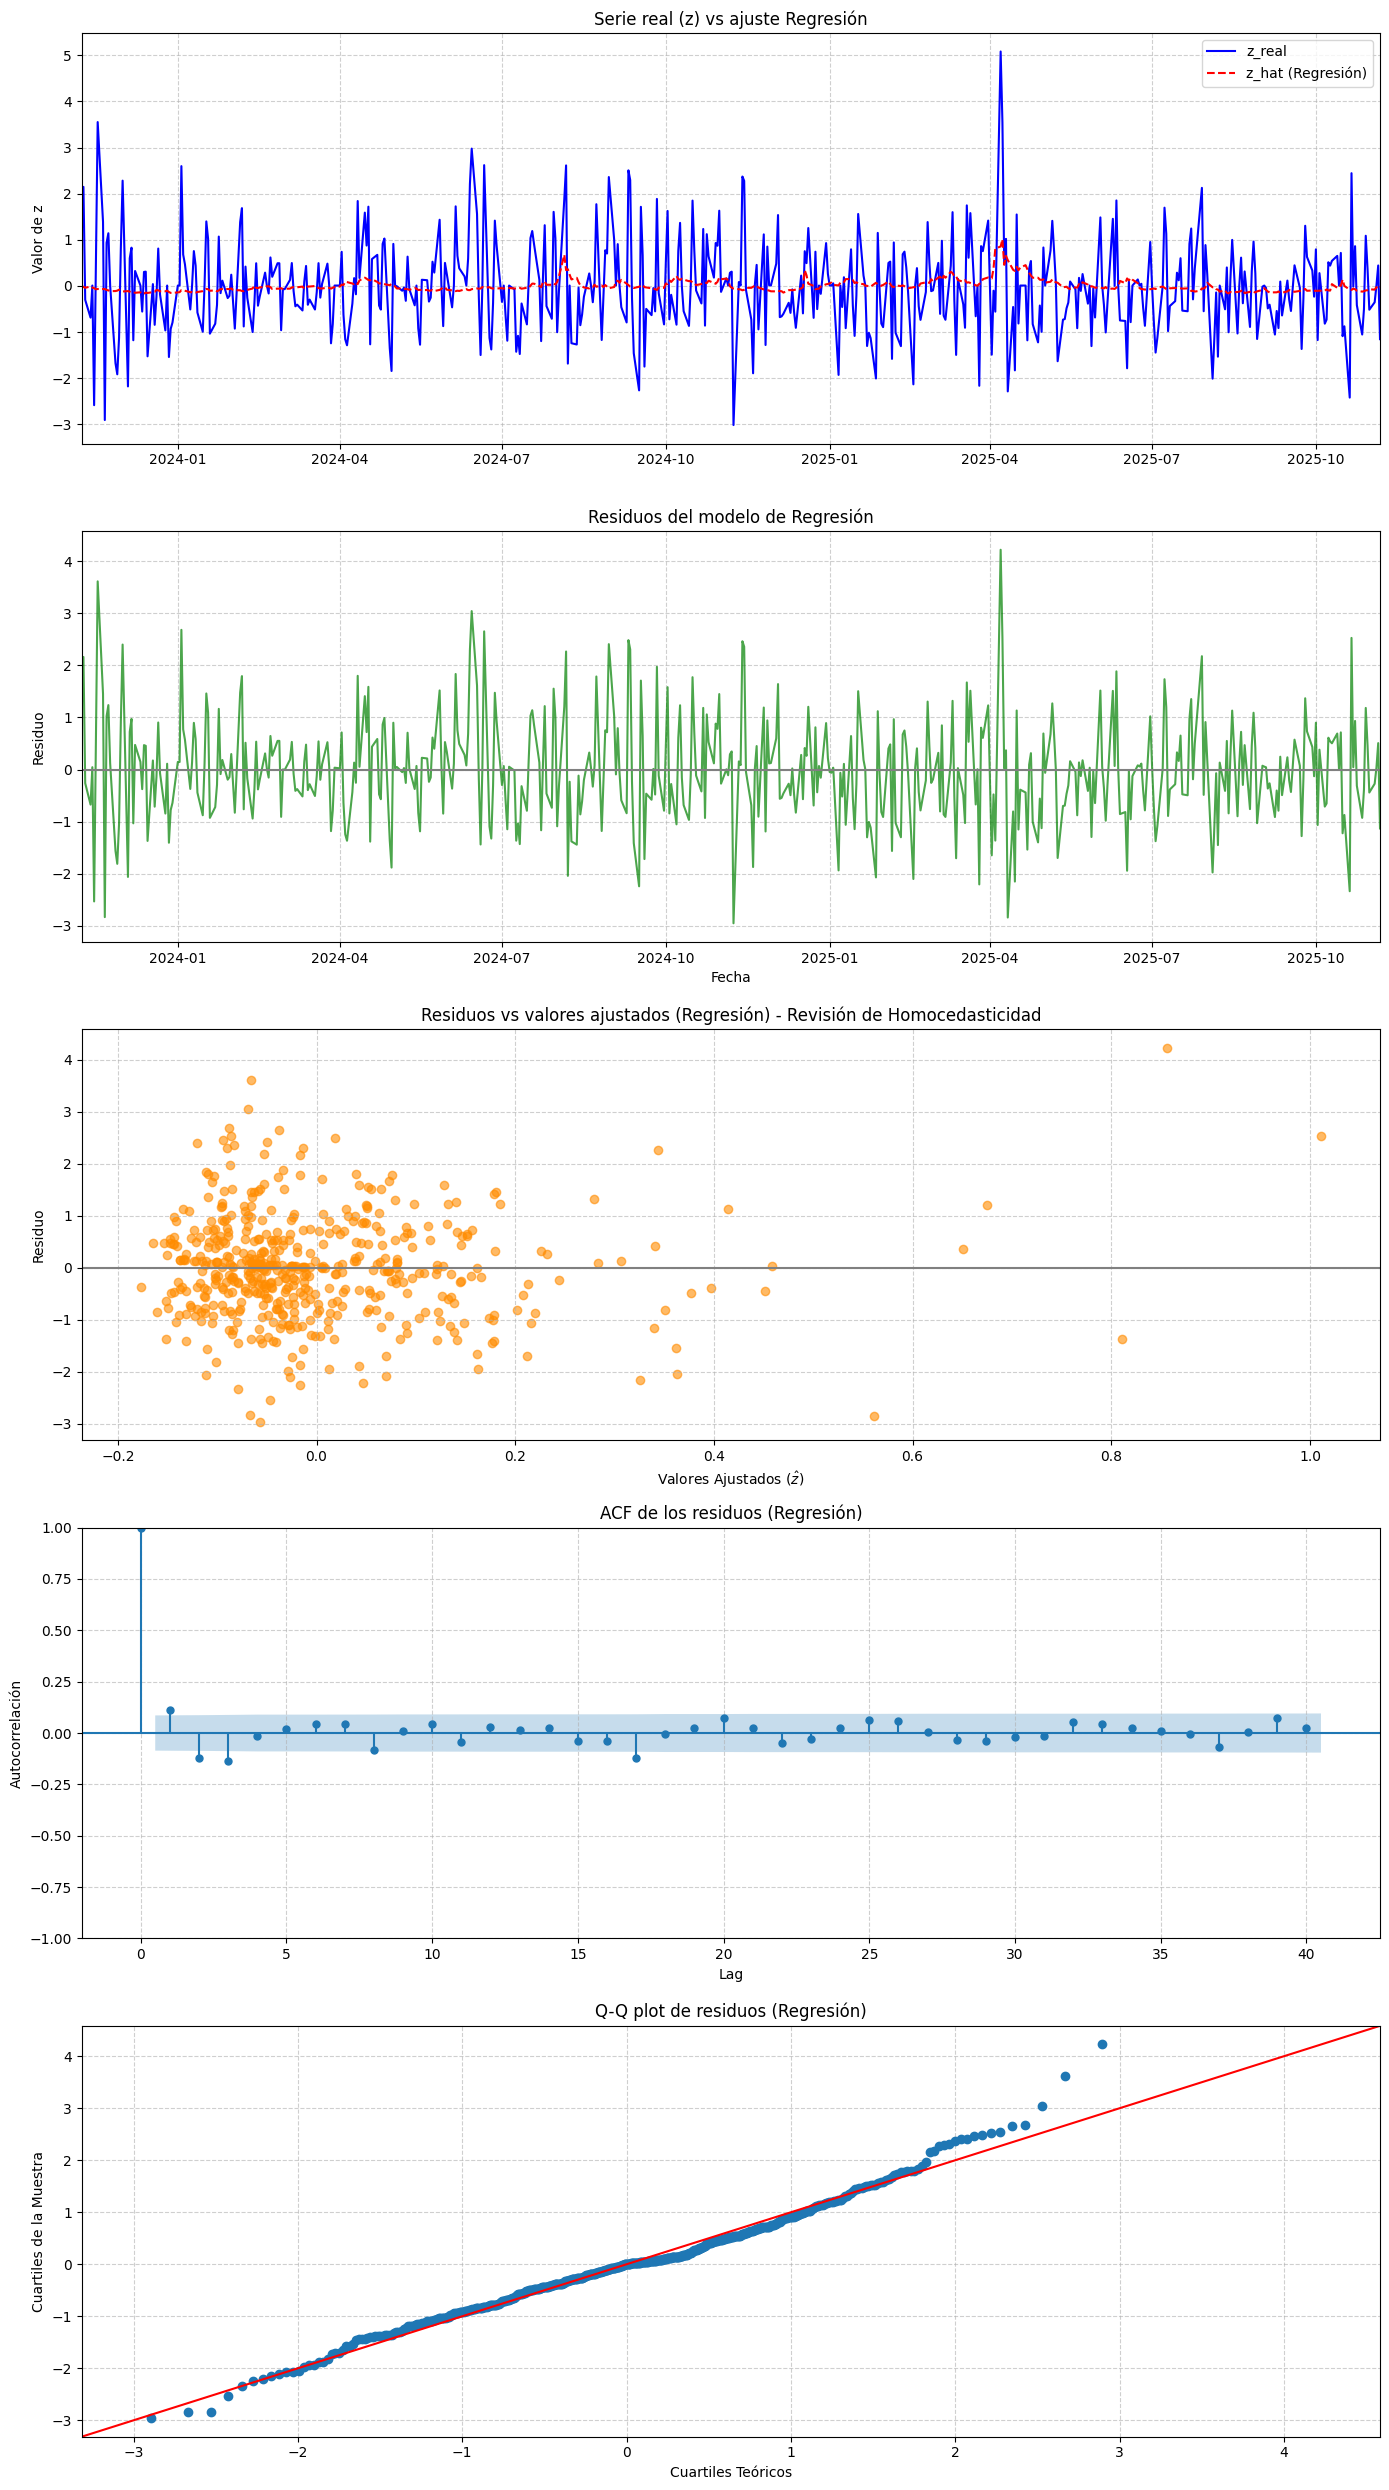


--- Test de Normalidad de Shapiro-Wilk ---
Estadístico Shapiro-Wilk: 0.9856, p-value: 0.0000
Hay evidencia de que los residuos del modelo de Regresión no siguen una distribución normal (p-value <= 0.05).


In [ ]:
# CELDA 019
'''
Esta celda diagnostica el modelo de regresión lineal múltiple (z ~ oil + dol_wg + vix):
- Compara la serie real (z) con la ajustada por el modelo.
- Analiza el comportamiento de los residuos (errores del modelo) a lo largo del tiempo.
- Revisa su autocorrelación para detectar patrones no capturados.
- Analiza la posible heterocedasticidad (si la varianza de los residuos es constante).
- Evalúa la normalidad de la distribución de los residuos mediante gráficos (histograma, Q-Q plot)
  y una prueba estadística (Shapiro-Wilk).
'''

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot # Para el Q-Q plot
from scipy.stats import shapiro # Para el test de Shapiro-Wilk
import os
import pandas as pd # Aunque ya está importado, buena práctica
import numpy as np # Aunque ya está importado, buena práctica
import seaborn as sns # Para mejorar histogramas con KDE

print("--- Diagnóstico del Modelo de Regresión Lineal Múltiple ---")

# Desde reg_df, extrae z_real, z_hat y resid
# reg_df fue generado en CELDA 018
z_real = reg_df['z_real']
z_hat = reg_df['z_hat']
resid = reg_df['resid']

# Imprime cuántas observaciones tiene resid, su media y su desviación estándar.
print(f"Número de observaciones en los residuos: {len(resid)}")
print(f"Media de los residuos: {resid.mean():.4f}")
print(f"Desviación estándar de los residuos: {resid.std():.4f}")

print("\n--- Visualización Completa del Diagnóstico ---")
# Crea una única figura con 5 subplots en columna (5 filas, 1 columna), con control independiente del eje X:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 25), sharex=False) # sharex=False para control individual de ejes X

# Obtener los límites de fecha del DataFrame para el eje X (para los plots de serie de tiempo)
xmin = z_real.index.min()
xmax = z_real.index.max()

# Subplot 1: z_real (azul) y z_hat (rojo punteado) vs tiempo
axes[0].plot(z_real.index, z_real, label='z_real', color='blue')
axes[0].plot(z_real.index, z_hat, label='z_hat (Regresión)', color='red', linestyle='--')
axes[0].set_title('Serie real (z) vs ajuste Regresión')
axes[0].set_ylabel('Valor de z')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xlim(xmin, xmax) # Establecer los límites del eje X

# Subplot 2: resid vs tiempo
axes[1].plot(resid.index, resid, label='Residuos', color='green', alpha=0.7)
axes[1].axhline(0, color='gray', linestyle='-') # Línea en 0 para referencia
axes[1].set_title('Residuos del modelo de Regresión')
axes[1].set_ylabel('Residuo')
axes[1].set_xlabel('Fecha') # Solo aquí para el eje de tiempo
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xlim(xmin, xmax) # Establecer los límites del eje X

# Subplot 3: gráfico de dispersión resid vs z_hat (para homocedasticidad)
axes[2].scatter(z_hat, resid, alpha=0.6, color='darkorange')
axes[2].axhline(0, color='gray', linestyle='-')
axes[2].set_title('Residuos vs valores ajustados (Regresión) - Revisión de Homocedasticidad')
axes[2].set_xlabel(r'Valores Ajustados ($\hat{z}$)') # Corregido: Usar r'' para raw string y \ para escapar \hat
axes[2].set_ylabel('Residuo')
axes[2].grid(True, linestyle='--', alpha=0.6)

# Subplot 4: ACF de resid usando plot_acf
plot_acf(resid, lags=40, ax=axes[3], title='ACF de los residuos (Regresión)')
axes[3].set_xlabel('Lag')
axes[3].set_ylabel('Autocorrelación')
axes[3].grid(True, linestyle='--', alpha=0.6)
# NOTA: plot_acf maneja su propio eje X de lags, no se fuerza el xlim de fechas.

# Subplot 5: Q-Q plot de resid frente a la normal usando qqplot con línea de 45°
qqplot(resid, line='45', ax=axes[4]) # line='45' añade la línea de referencia diagonal
axes[4].set_title('Q-Q plot de residuos (Regresión)')
axes[4].set_xlabel('Cuartiles Teóricos')
axes[4].set_ylabel('Cuartiles de la Muestra')
axes[4].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ajustar el diseño para evitar superposiciones

# Guardar la figura en la carpeta figuras ANTES de mostrarla
file_path_diagnostico_reg = os.path.join(figuras, "diagnostico_completo_regresion.png")
plt.savefig(file_path_diagnostico_reg)
print(f"Figura de diagnóstico completo del modelo de Regresión guardada en: {file_path_diagnostico_reg}") # Indicando el nombre del archivo generado

plt.show() # Mostrar la figura
plt.close(fig) # CERRAR la figura explícitamente después de mostrarla

print("\n--- Test de Normalidad de Shapiro-Wilk ---")
# Aplica la prueba de Shapiro-Wilk a resid con shapiro.
shapiro_test = shapiro(resid)
print(f"Estadístico Shapiro-Wilk: {shapiro_test.statistic:.4f}, p-value: {shapiro_test.pvalue:.4f}")

# Imprime un mensaje corto interpretando el p-valor
if shapiro_test.pvalue > 0.05:
    print("No se rechaza la normalidad de los residuos del modelo de Regresión (p-value > 0.05).")
else:
    print("Hay evidencia de que los residuos del modelo de Regresión no siguen una distribuci\u00F3n normal (p-value <= 0.05).")

In [ ]:
# CELDA 020
'''
Esta celda ajusta un modelo "mixto" o ARX(3) donde la variable dependiente 'z'
depende de sus propios rezagos (z_lag1, z_lag2, z_lag3), de sus promedios móviles
(ma5_z, sd5_z) y de las variables externas (oil, dol_wg, vix).
Se calcularán métricas de error (MAE, RMSE y R²) para comparar su rendimiento
con los modelos univariados y de regresión simple previamente evaluados.
'''

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

print("--- Ajustando Modelo de Regresión Lineal ARX(3) ---")

# Usar la función preparar_dataset para crear un DataFrame limpio con las columnas necesarias.
cols_arx = ['z', 'z_lag1', 'z_lag2', 'z_lag3', 'ma5_z', 'sd5_z', 'oil', 'dol_wg', 'vix']
df_arx = preparar_dataset(cols_arx)

print(f"DataFrame para modelo ARX(3) creado con forma: {df_arx.shape}")
print(f"Rango de fechas: Desde {df_arx.index.min().strftime('%Y-%m-%d')} hasta {df_arx.index.max().strftime('%Y-%m-%d')}")

# Definir la variable dependiente (y) y las variables independientes (X)
y = df_arx['z']
X = df_arx[['z_lag1', 'z_lag2', 'z_lag3', 'ma5_z', 'sd5_z', 'oil', 'dol_wg', 'vix']]

# Agregar una constante a X para incluir el intercepto en el modelo
X_const = sm.add_constant(X)

# Ajustar un modelo OLS (Ordinary Least Squares) con statsmodels
modelo_arx = sm.OLS(y, X_const)
ajuste_arx = modelo_arx.fit()

print("\n--- Resumen del Modelo ARX(3) ---")
# Imprimir un resumen corto: al menos los coeficientes estimados de cada regresor y el R².
print(ajuste_arx.summary2().tables[1]) # Coeficientes
print(f"R-cuadrado (R²): {ajuste_arx.rsquared:.4f}") # R-cuadrado

# Obtener los valores ajustados (pronósticos in-sample)
z_hat_arx = ajuste_arx.fittedvalues

# Crear un DataFrame arx_df con z_real, z_hat y resid
arx_df = pd.DataFrame({
    'z_real': y,
    'z_hat': z_hat_arx,
    'resid': y - z_hat_arx
})
# Asegurarse de que el índice se mantiene para el diagnóstico temporal
arx_df.index = y.index

# Calcular MAE y RMSE del modelo ARX
mae_arx = mean_absolute_error(arx_df['z_real'], arx_df['z_hat'])
rmse_arx = np.sqrt(mean_squared_error(arx_df['z_real'], arx_df['z_hat']))

print("\n--- Métricas de Error del Modelo ARX(3) ---")
print(f"MAE del modelo ARX(3): {mae_arx:.4f}")
print(f"RMSE del modelo ARX(3): {rmse_arx:.4f}")
print("Este modelo ARX(3) es el más completo hasta ahora, combinando rezagos de 'z', promedios móviles y variables externas.")
print("El DataFrame 'arx_df' se usará para un diagnóstico de residuos en una celda posterior.")

print("\n--- Vista rápida del DataFrame de pronósticos ARX(3) ---")
# Mostrar arx_df.head() para ver z_real, z_hat y resid.
display(arx_df.head())

print("\n--- Guardando resultados del modelo ARX(3) ---")
# Guardar una pequeña tabla de resultados en la carpeta outputs
resultados_arx = pd.DataFrame({
    'modelo': ['ARX3_z_ma5_sd5_oil_dolwg_vix'],
    'MAE': [mae_arx],
    'RMSE': [rmse_arx],
    'R2': [ajuste_arx.rsquared]
})

file_path_resultados_arx = os.path.join(outputs, "resultados_arx.csv")
resultados_arx.to_csv(file_path_resultados_arx, index=False)
print(f"Tabla de resultados del modelo ARX(3) guardada en: {file_path_resultados_arx}")

--- Ajustando Modelo de Regresión Lineal ARX(3) ---
Preparando dataset con las columnas: ['z', 'z_lag1', 'z_lag2', 'z_lag3', 'ma5_z', 'sd5_z', 'oil', 'dol_wg', 'vix']
DataFrame para modelo ARX(3) creado con forma: (518, 9)
Rango de fechas: Desde 2023-11-14 hasta 2025-11-06

--- Resumen del Modelo ARX(3) ---
           Coef.  Std.Err.          t         P>|t|    [0.025    0.975]
const  -0.471111  1.420128  -0.331738  7.402234e-01 -3.261144  2.318923
z_lag1 -0.381949  0.038575  -9.901349  2.961042e-21 -0.457736 -0.306162
z_lag2 -0.495451  0.035484 -13.962695  9.642456e-38 -0.565164 -0.425738
z_lag3 -0.614348  0.038537 -15.941826  1.052165e-46 -0.690059 -0.538637
ma5_z   2.498592  0.114120  21.894508  2.276669e-75  2.274389  2.722795
sd5_z  -0.074567  0.074523  -1.000600  3.174956e-01 -0.220977  0.071842
oil    -0.001074  0.005277  -0.203588  8.387570e-01 -0.011442  0.009293
dol_wg  0.004331  0.011870   0.364890  7.153448e-01 -0.018989  0.027652
vix     0.004641  0.007948   0.583966  5.59

,z_real,z_hat,resid
date,,,
2023-11-14,0.009148,0.159980,-0.150831
2023-11-15,-2.583121,-0.272940,-2.310182
2023-11-16,0.476405,-0.183409,0.659814
2023-11-17,3.551424,1.345683,2.205741
2023-11-20,1.387678,1.278132,0.109546



--- Guardando resultados del modelo ARX(3) ---
Tabla de resultados del modelo ARX(3) guardada en: /content/t10drive/MyDrive/taller10/outputs/resultados_arx.csv


--- Diagnóstico del Modelo ARX(3) ---
Número de observaciones en los residuos: 518
Media de los residuos: 0.0000
Desviación estándar de los residuos: 0.6903

--- Visualización Completa del Diagnóstico ---
Figura de diagnóstico completo del modelo ARX(3) guardada en: /content/t10drive/MyDrive/taller10/outputs/figuras/diagnostico_completo_arx3.png


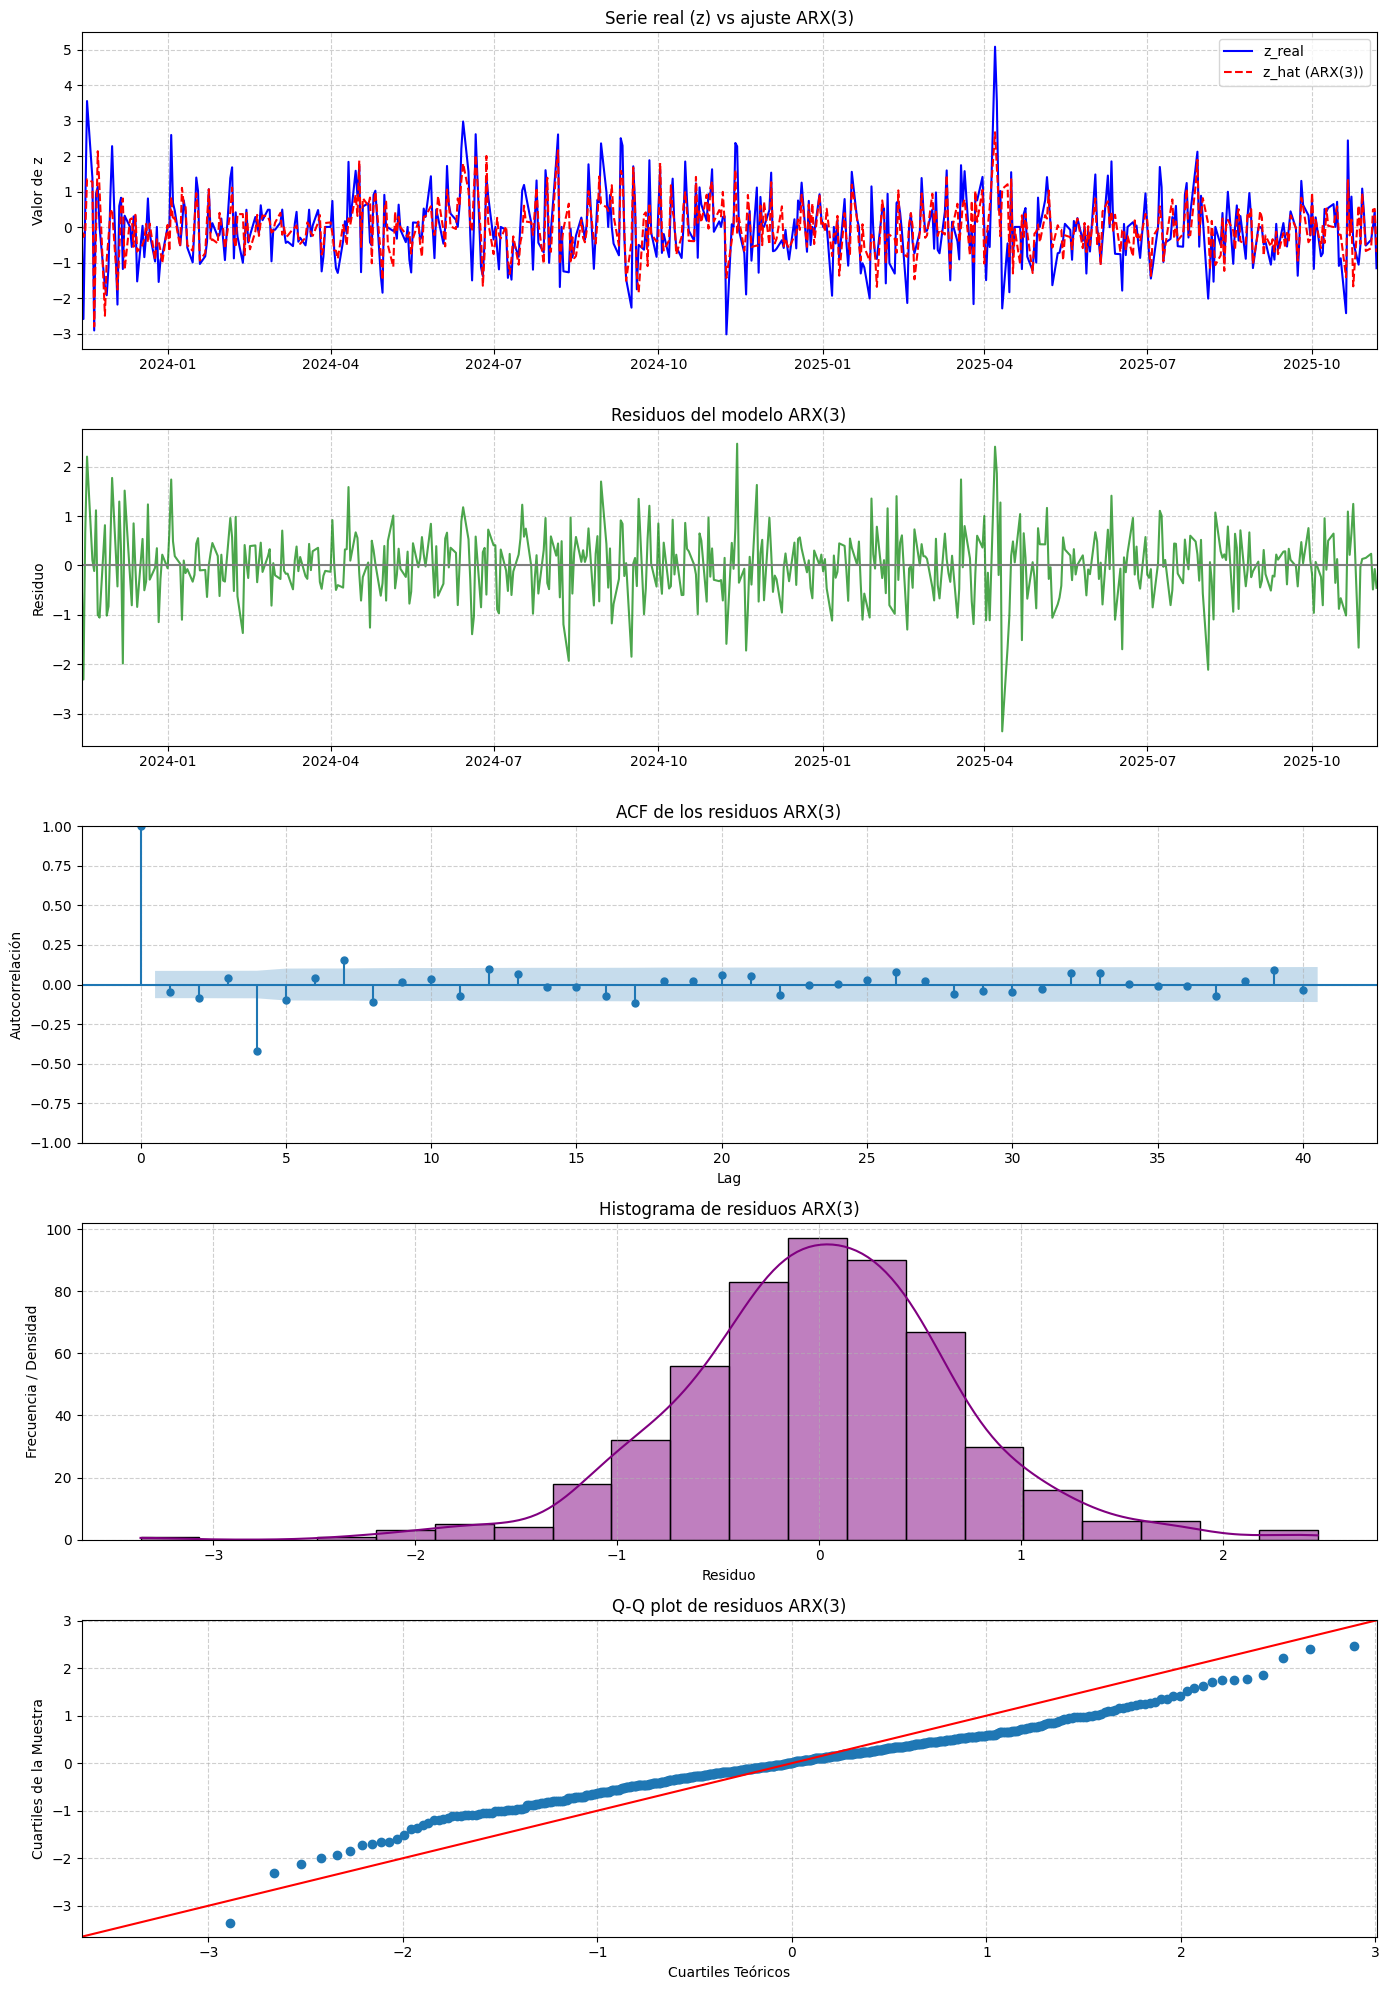


--- Test de Normalidad de Shapiro-Wilk ---
Estadístico Shapiro-Wilk: 0.9832, p-value: 0.0000
Hay evidencia de que los residuos del modelo ARX(3) no siguen una distribución normal (p-value <= 0.05).


In [ ]:
# CELDA 021
'''
Esta celda diagnostica el modelo ARX(3):
- Compara la serie real (z) con la ajustada por el modelo.
- Analiza el comportamiento de los residuos (errores del modelo) a lo largo del tiempo.
- Revisa su autocorrelación para detectar patrones no capturados.
- Evalúa la normalidad de la distribución de los residuos mediante gráficos (histograma, Q-Q plot)
  y el test estadístico de Shapiro-Wilk.
'''

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot # Para el Q-Q plot
from scipy.stats import shapiro # Para el test de Shapiro-Wilk
import os
import pandas as pd # Asegurarse de que pandas esté importado
import numpy as np # Asegurarse de que numpy esté importado
import seaborn as sns # Para mejorar histogramas con KDE

print("--- Diagnóstico del Modelo ARX(3) ---")

# Desde arx_df, extrae z_real, z_hat y resid
# arx_df fue generado en CELDA 020
z_real = arx_df['z_real']
z_hat = arx_df['z_hat']
resid = arx_df['resid']

# Imprime cuántas observaciones tiene resid, su media y su desviación estándar.
print(f"Número de observaciones en los residuos: {len(resid)}")
print(f"Media de los residuos: {resid.mean():.4f}")
print(f"Desviación estándar de los residuos: {resid.std():.4f}")

print("\n--- Visualización Completa del Diagnóstico ---")
# Crea una única figura con 5 subplots en columna (5 filas, 1 columna), con control independiente del eje X:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 20), sharex=False) # sharex=False para control individual de ejes X

# Obtener los límites de fecha del DataFrame para el eje X (para los plots de serie de tiempo)
xmin = z_real.index.min()
xmax = z_real.index.max()

# Subplot 1: z_real en azul y z_hat en rojo punteado vs tiempo
axes[0].plot(z_real.index, z_real, label='z_real', color='blue')
axes[0].plot(z_real.index, z_hat, label='z_hat (ARX(3))', color='red', linestyle='--')
axes[0].set_title('Serie real (z) vs ajuste ARX(3)')
axes[0].set_ylabel('Valor de z')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xlim(xmin, xmax) # Establecer los límites del eje X

# Subplot 2: resid vs tiempo
axes[1].plot(resid.index, resid, label='Residuos', color='green', alpha=0.7)
axes[1].axhline(0, color='gray', linestyle='-') # Línea en 0 para referencia
axes[1].set_title('Residuos del modelo ARX(3)')
axes[1].set_ylabel('Residuo')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xlim(xmin, xmax) # Establecer los límites del eje X

# Subplot 3: ACF de resid usando plot_acf
plot_acf(resid, lags=40, ax=axes[2], title='ACF de los residuos ARX(3)')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('Autocorrelación')
axes[2].grid(True, linestyle='--', alpha=0.6)
# NOTA: plot_acf maneja su propio eje X de lags, no se fuerza el xlim de fechas.

# Subplot 4: histograma de resid (bins=20)
sns.histplot(resid, bins=20, kde=True, ax=axes[3], color='purple')
axes[3].set_title('Histograma de residuos ARX(3)')
axes[3].set_xlabel('Residuo')
axes[3].set_ylabel('Frecuencia / Densidad')
axes[3].grid(True, linestyle='--', alpha=0.6)

# Subplot 5: Q-Q plot de resid frente a la normal con qqplot (línea 45°)
qqplot(resid, line='45', ax=axes[4]) # line='45' añade la línea de referencia diagonal
axes[4].set_title('Q-Q plot de residuos ARX(3)')
axes[4].set_xlabel('Cuartiles Teóricos')
axes[4].set_ylabel('Cuartiles de la Muestra')
axes[4].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ajustar el diseño para evitar superposiciones

# Guardar la figura en la carpeta figuras ANTES de mostrarla
file_path_diagnostico_arx3 = os.path.join(figuras, "diagnostico_completo_arx3.png")
plt.savefig(file_path_diagnostico_arx3)
print(f"Figura de diagnóstico completo del modelo ARX(3) guardada en: {file_path_diagnostico_arx3}") # Indicando el nombre del archivo generado

plt.show() # Mostrar la figura
plt.close(fig) # CERRAR la figura explícitamente después de mostrarla

print("\n--- Test de Normalidad de Shapiro-Wilk ---")
# Aplica la prueba de Shapiro-Wilk a resid con shapiro.
shapiro_test = shapiro(resid)
print(f"Estadístico Shapiro-Wilk: {shapiro_test.statistic:.4f}, p-value: {shapiro_test.pvalue:.4f}")

# Imprime un mensaje corto interpretando el p-valor
if shapiro_test.pvalue > 0.05:
    print("No se rechaza la normalidad de los residuos del modelo ARX(3) (p-value > 0.05).")
else:
    print("Hay evidencia de que los residuos del modelo ARX(3) no siguen una distribución normal (p-value <= 0.05).")

In [ ]:
# CELDA 022
'''
Esta celda resume y compara las métricas de error (MAE y RMSE) de todos los modelos
de pronóstico que han sido probados sobre la serie 'z'. Recopila los resultados
de los archivos CSV generados por las celdas anteriores, los unifica en una tabla
y la muestra ordenada por rendimiento.
'''

import pandas as pd
import os

print("--- Creando tabla comparativa de modelos ---")

# Lista para almacenar los resultados de cada modelo
lista_resultados = []

# Rutas base para los archivos de resultados
outputs_path = outputs # 'outputs' es una variable definida en celdas anteriores

# --- Cargar y procesar resultados del modelo PMS ---
file_pms = os.path.join(outputs_path, "resultados_pms.csv")
if os.path.exists(file_pms):
    df_pms = pd.read_csv(file_pms)
    # Seleccionar la fila correspondiente a la ventana 20
    pms_best = df_pms[df_pms['ventana'] == 20].copy()
    pms_best['modelo'] = "PMS_20"
    lista_resultados.append(pms_best[['modelo', 'MAE', 'RMSE']])
    print(f"Resultados de PMS (ventana 20) cargados. MAE: {pms_best['MAE'].iloc[0]:.4f}, RMSE: {pms_best['RMSE'].iloc[0]:.4f}")
else:
    print(f"Advertencia: No se encontró el archivo {file_pms}")

# --- Cargar y procesar resultados del modelo SES ---
file_ses = os.path.join(outputs_path, "resultados_ses.csv")
if os.path.exists(file_ses):
    df_ses = pd.read_csv(file_ses)
    df_ses['modelo'] = "SES"
    lista_resultados.append(df_ses[['modelo', 'MAE', 'RMSE']])
    print(f"Resultados de SES cargados. MAE: {df_ses['MAE'].iloc[0]:.4f}, RMSE: {df_ses['RMSE'].iloc[0]:.4f}")
else:
    print(f"Advertencia: No se encontró el archivo {file_ses}")

# --- Cargar y procesar resultados del modelo ETS ---
file_ets = os.path.join(outputs_path, "resultados_ets.csv")
if os.path.exists(file_ets):
    df_ets = pd.read_csv(file_ets)
    df_ets['modelo'] = "ETS_simple"
    lista_resultados.append(df_ets[['modelo', 'MAE', 'RMSE']])
    print(f"Resultados de ETS simple cargados. MAE: {df_ets['MAE'].iloc[0]:.4f}, RMSE: {df_ets['RMSE'].iloc[0]:.4f}")
else:
    print(f"Advertencia: No se encontró el archivo {file_ets}")

# --- Cargar y procesar resultados del modelo AR ---
file_ar = os.path.join(outputs_path, "resultados_ar.csv")
if os.path.exists(file_ar):
    df_ar = pd.read_csv(file_ar)
    # Seleccionar la fila correspondiente al orden 3 (AR_3)
    ar_best = df_ar[df_ar['orden_p'] == 3].copy()
    ar_best['modelo'] = "AR_3"
    lista_resultados.append(ar_best[['modelo', 'MAE', 'RMSE']])
    print(f"Resultados de AR(3) cargados. MAE: {ar_best['MAE'].iloc[0]:.4f}, RMSE: {ar_best['RMSE'].iloc[0]:.4f}")
else:
    print(f"Advertencia: No se encontró el archivo {file_ar}")

# --- Cargar y procesar resultados del modelo de Regresión Multivariada ---
file_reg = os.path.join(outputs_path, "resultados_regresion_multivariada.csv")
if os.path.exists(file_reg):
    df_reg = pd.read_csv(file_reg)
    df_reg['modelo'] = "REG_z_oil_dolwg_vix"
    lista_resultados.append(df_reg[['modelo', 'MAE', 'RMSE']])
    print(f"Resultados de Regresión Multivariada cargados. MAE: {df_reg['MAE'].iloc[0]:.4f}, RMSE: {df_reg['RMSE'].iloc[0]:.4f}")
else:
    print(f"Advertencia: No se encontró el archivo {file_reg}")

# --- Cargar y procesar resultados del modelo ARX ---
file_arx = os.path.join(outputs_path, "resultados_arx.csv")
if os.path.exists(file_arx):
    df_arx = pd.read_csv(file_arx)
    df_arx['modelo'] = "ARX3_completo"
    lista_resultados.append(df_arx[['modelo', 'MAE', 'RMSE']])
    print(f"Resultados de ARX(3) cargados. MAE: {df_arx['MAE'].iloc[0]:.4f}, RMSE: {df_arx['RMSE'].iloc[0]:.4f}")
else:
    print(f"Advertencia: No se encontró el archivo {file_arx}")

# --- Construir el DataFrame resumen_modelos ---
if lista_resultados:
    resumen_modelos = pd.concat(lista_resultados, ignore_index=True)
    resumen_modelos = resumen_modelos.sort_values(by='RMSE', ascending=True)

    print("\n--- Tabla Comparativa de Modelos (ordenada por RMSE) ---")
    display(resumen_modelos)

    # Identificar el modelo con el menor RMSE
    mejor_modelo_general = resumen_modelos.iloc[0]
    print(f"\nEl modelo con el menor RMSE es: {mejor_modelo_general['modelo']} con un RMSE de {mejor_modelo_general['RMSE']:.4f}")

    # Guardar la tabla de resumen
    file_path_resumen = os.path.join(outputs_path, "resumen_modelos_z.csv")
    resumen_modelos.to_csv(file_path_resumen, index=False)
    print(f"Tabla comparativa de modelos guardada en: {file_path_resumen}")
else:
    print("No se pudieron cargar resultados de ningùn modelo para la comparación.")

--- Creando tabla comparativa de modelos ---
Resultados de PMS (ventana 20) cargados. MAE: 0.7522, RMSE: 0.9899
Resultados de SES cargados. MAE: 0.7397, RMSE: 0.9990
Resultados de ETS simple cargados. MAE: 0.7397, RMSE: 0.9990
Resultados de AR(3) cargados. MAE: 0.7380, RMSE: 0.9736
Resultados de Regresión Multivariada cargados. MAE: 0.7423, RMSE: 0.9898
Resultados de ARX(3) cargados. MAE: 0.5203, RMSE: 0.6897

--- Tabla Comparativa de Modelos (ordenada por RMSE) ---


,modelo,MAE,RMSE
5,ARX3_completo,0.520341,0.689681
3,AR_3,0.738029,0.973609
4,REG_z_oil_dolwg_vix,0.742284,0.989817
0,PMS_20,0.752247,0.989861
2,ETS_simple,0.739727,0.999042
1,SES,0.739727,0.999042



El modelo con el menor RMSE es: ARX3_completo con un RMSE de 0.6897
Tabla comparativa de modelos guardada en: /content/t10drive/MyDrive/taller10/outputs/resumen_modelos_z.csv
